# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Abstract

This capstone asks which content pages, among those with strong organic search visibility, are plausible candidates for AI-referral traffic pickup — extending a lane first framed on a 30,000-row sample to FlyRank's full search-intelligence warehouse. This gap is a real, unsolved prioritization problem inside FlyRank today — content teams have no existing tool to decide which visible pages are worth restructuring for AI-referral capture, and this capstone is a first attempt at building one. A within-client normalized composite score, built from two GSC-derived features (search impressions and word count), ranks 266,175 eligible articles and is evaluated against a naive impressions-only baseline on a held-out, client-grouped test split. The scored approach outperforms the naive baseline at every K tested (8.76x lift at K=500 versus 7.18x), and a deliberate leakage check confirms the evaluation pipeline correctly detects an artificially inflated result. However, a paired bootstrap test shows this margin is not statistically distinguishable from chance given the small number of independent test clients available. The result is reported as directionally promising and worth further validation on a larger client population — framed throughout as decision-support for human review, not a validated predictive model.

## 2. Question

*The research question and the decision it supports.*

**Lane:** Freestyle — AI Referral Opportunity Scoring, extended to the full warehouse.

**Question:** Among pages that already have strong organic search visibility, which ones look like plausible candidates for AI-referral pickup based on traits shared with pages that already receive AI-referral sessions — and can those candidates be ranked in a way that beats a naive impressions-only rule?

**Why this, at capstone scale:** Weeks 1–4 established this on the 30,000-row starter sample: AI-referral sessions are rare (6.43% of pages), concentrated among higher-impression, longer-content pages, and — counterintuitively — not concentrated among top-position pages. The capstone moves the same question onto the full `FlyRank/internship-warehouse` release (~79M rows, `fact_content_daily_performance` + `fact_content_query_90d`), where the AI-referral signal (`sessions_ai`) can be aggregated over a properly windowed, leakage-safe period instead of a single fixed 90-day snapshot, and where the client-concentration issue found in Week 2 can be tested at real scale rather than assumed away.

**The decision this supports:** which pages a content team should prioritize when trying to grow AI-tool referral traffic — a prioritization problem with no existing tooling at FlyRank today.

**The action a strategist could take:** given a ranked, reason-coded list of AI-opportunity pages (high search visibility, structurally similar to pages that already get AI sessions, but currently receiving none), restructure those pages first — clearer definitions, more explicit answer framing — and monitor for AI-session lift afterward.

**The cost of a wrong call:** low but not zero. A false positive costs editorial time on a page that doesn't lift. The larger risk, as in Week 1, is overclaiming: this model ranks *opportunity*, not *causation* — it cannot show that any content trait causes AI pickup, only that AI-session pages and candidate pages share observable traits.

**What's new versus Weeks 1–4:** full warehouse scale instead of the 30k sample; a defined, leakage-checked aggregation window for `sessions_ai` instead of a static column; validation against a real train/test split rather than descriptive stats alone; and — if this holds up — a stretch attempt at whether AI-opportunity pages that get restructured show measurable session growth in a later window (tying into the growth/momentum stretch goal noted in Week 1).

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

In [2]:
# Anchor check: re-confirm the starter-sample numbers this question is built on
# (full warehouse-scale version of this comes in Section 2 — this is just grounding, not new analysis)
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
has_ai = df["ai_sessions_90d"] > 0

print(f"AI-session pages: {has_ai.mean()*100:.2f}% ({has_ai.sum()} of {len(df)})")
print(f"Median impressions_90d — no AI: {df[~has_ai]['impressions_90d'].median():.0f} | has AI: {df[has_ai]['impressions_90d'].median():.0f}")
print(f"Median avg_position   — no AI: {df[~has_ai]['avg_position'].median():.1f} | has AI: {df[has_ai]['avg_position'].median():.1f}")

AI-session pages: 6.43% (1930 of 30000)
Median impressions_90d — no AI: 630 | has AI: 8014
Median avg_position   — no AI: 10.5 | has AI: 15.3


## 3. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** `FlyRank/internship-warehouse` (Hugging Face, gated), frozen snapshot export 2026-07-03.

**Tables used:**
- `fact_content_daily_performance` — grain `(client_hash_id, content_hash_id, report_date)`, partitioned by `month=YYYY-MM`. This is the daily source for both the label (`sessions_ai`) and the rolled-up features (`gsc_impressions`, `gsc_clicks`, `gsc_avg_position`).
- `dim_content` — static content attributes, joined for `word_count`.
- `dim_clients` — joined only to interpret `access_profile` against row-level flags, never used to filter directly (per the stale-label finding below).
- `fact_content_query_90d` — not used in this section; reserved for a possible query-level feature pass in Methodology if the article-level score needs more signal.

**Date window:** the data contract (ML-04) established `month=2026-03` as the safe development month, with the `_sample` file (June 2026) sealed off as the natural outcome window for any past→future label — reusing it here for development would leak the future into training. The capstone keeps that boundary: development and feature-building stay in past months; if a forward-looking label is attempted (Methodology, section 4), the held-out future window is defined explicitly there, not borrowed from `_sample`.

Because ML-04 showed the AI-referral base rate depends heavily on the aggregation window (0.0562% daily → 1.15% monthly → 6.43% at 90 days in the starter CSV), this capstone aggregates `sessions_ai` over a wider multi-month window rather than a single calendar month, to get a base rate closer to what the scoring work in ML-03 was actually tuned against. The exact window is fixed and verified below.

**Exclusions carried forward from the ML-04 contract, with reasons:**
- Rows on `dim_content.is_deleted = True` — a deleted article's past performance says nothing about future opportunity (~2% of fact rows in the March slice).
- Articles with fewer than 14 days of history in the window — insufficient for a stable rolled-up signal; the same 14-day floor used for label-window computability in ML-04/ML-05.
- `client_hash_id` filtering by `dim_clients.access_profile` is **not** used — ML-04 found this field stale for at least 2 clients (`no_search_or_analytics_access` clients with real GSC data present). Row-level `gsc_data_available` / `ga4_data_available` flags drive filtering instead.
- Rows where `ga4_data_available IS NULL` (true "no GA4 access," ~31% of rows) are excluded from any `sessions_ai`-based calculation — this is structurally missing, not a measured zero. Rows where the flag is `False` (measured zero engagement) are kept and treated as real zeros, not dropped.

**Filter gap discovered during Section 6 (documented here, not silently patched):** the eligibility filter above excludes on `is_deleted`, `ga4_data_available IS NOT NULL`, and 14-day history — but does not check GSC availability. This let 6 clients (42,734 article-rows) with `gsc_data_available = False` across their *entire* window pass through as "eligible," despite having zero usable `gsc_impressions`/`gsc_avg_position` signal. One of these six (`client_625b6439094e23e4`) also shows a `dim_clients.gsc_data_start` value (2025-07-01) that contradicts the complete absence of GSC data — a second, independently-discovered instance of the client-metadata staleness ML-04 first found in `access_profile`. These 6 clients' articles are retained in the feature table (for transparency) but explicitly labeled `insufficient_data` in Section 6 rather than scored, since neither the score nor a "recommend" or "don't recommend" call can be made without GSC signal.

**Public-safe note:** no client names, domains, or raw query strings are retained past this section — all identifiers used downstream are the salted hash keys already provided by the release.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import duckdb
from huggingface_hub import login, hf_hub_download
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))
repo = "FlyRank/internship-warehouse"

# TODO: confirm final window (list of month partitions) before running at scale
MONTHS = ["2026-03"]  # placeholder — extend once window is finalized

fact_paths = [
    hf_hub_download(repo_id=repo, repo_type="dataset",
                     filename=f"fact_content_daily_performance/month={m}/data_0.parquet")
    for m in MONTHS
]

dim_clients_path = hf_hub_download(repo_id=repo, repo_type="dataset", filename="dim_clients.parquet")
dim_content_path = hf_hub_download(repo_id=repo, repo_type="dataset", filename="dim_content.parquet")

con = duckdb.connect()
con.sql(f"CREATE OR REPLACE VIEW fact AS SELECT * FROM read_parquet({fact_paths})")
con.sql(f"CREATE OR REPLACE VIEW dim_clients AS SELECT * FROM read_parquet('{dim_clients_path}')")
con.sql(f"CREATE OR REPLACE VIEW dim_content AS SELECT * FROM read_parquet('{dim_content_path}')")

for view in ["fact", "dim_clients", "dim_content"]:
    n = con.sql(f"SELECT COUNT(*) AS n_rows FROM {view}").df()["n_rows"][0]
    print(f"{view}: {n:,} rows")

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

dim_clients.parquet: reconstructing file:   0%|          |  0.00B / 3.38kB            

dim_clients.parquet: downloading bytes:           |  0.00B            

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

fact: 9,841,378 rows
dim_clients: 104 rows
dim_content: 519,606 rows


In [4]:
# Exclusion counts — how much of the raw window survives each filter
con.sql("""
    WITH base AS (
        SELECT f.*, d.is_deleted, d.word_count
        FROM fact f
        LEFT JOIN dim_content d USING (content_hash_id)
    ),
    history AS (
        SELECT content_hash_id, COUNT(DISTINCT report_date) AS days_present
        FROM fact
        GROUP BY content_hash_id
    )
    SELECT
        COUNT(*) AS raw_rows,
        SUM(CASE WHEN is_deleted THEN 1 ELSE 0 END) AS deleted_content_rows,
        SUM(CASE WHEN ga4_data_available IS NULL THEN 1 ELSE 0 END) AS no_ga4_access_rows
    FROM base
""").df()

,raw_rows,deleted_content_rows,no_ga4_access_rows
0,9841378,201090.0,3018741.0


In [5]:
# Article-level history depth check against the 14-day floor
history = con.sql("""
    SELECT content_hash_id, COUNT(DISTINCT report_date) AS days_present
    FROM fact
    GROUP BY content_hash_id
""").df()

print(f"Articles total: {len(history):,}")
print(f"Articles below 14-day floor: {(history['days_present'] < 14).sum():,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Articles total: 331,437
Articles below 14-day floor: 10,755


In [6]:
# Grain check — should return 0 rows
grain_check = con.sql("""
    SELECT report_date, client_hash_id, content_hash_id, COUNT(*) AS n
    FROM fact
    GROUP BY 1, 2, 3
    HAVING COUNT(*) > 1
""").df()
print("Duplicate grain rows found:", len(grain_check))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Duplicate grain rows found: 0


In [7]:
# Base rate for the chosen window, after applying the stated exclusions
# (deleted content, GA4-access rows only, 14-day-history articles only)
eligible = con.sql("""
    WITH history AS (
        SELECT content_hash_id, COUNT(DISTINCT report_date) AS days_present
        FROM fact
        GROUP BY content_hash_id
    ),
    filtered AS (
        SELECT f.content_hash_id, f.sessions_ai
        FROM fact f
        JOIN dim_content d USING (content_hash_id)
        JOIN history h USING (content_hash_id)
        WHERE d.is_deleted = FALSE
          AND f.ga4_data_available IS NOT NULL
          AND h.days_present >= 14
    )
    SELECT
        content_hash_id,
        SUM(sessions_ai) AS sessions_ai_window
    FROM filtered
    GROUP BY content_hash_id
""").df()

has_ai = eligible["sessions_ai_window"] > 0
print(f"Eligible articles: {len(eligible):,}")
print(f"Base rate this window: {has_ai.mean()*100:.2f}% ({has_ai.sum():,} of {len(eligible):,})")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Eligible articles: 245,550
Base rate this window: 1.54% (3,773 of 245,550)


In [8]:
# word_count coverage on the eligible article set
con.sql("""
    SELECT
        COUNT(*) AS n_content_rows,
        COUNT(word_count) AS n_with_word_count,
        ROUND(100.0 * COUNT(word_count) / COUNT(*), 2) AS pct_with_word_count
    FROM dim_content
    WHERE content_hash_id IN (SELECT DISTINCT content_hash_id FROM fact)
""").df()

,n_content_rows,n_with_word_count,pct_with_word_count
0,331437,224008,67.59


**Verified on `month=2026-03`:**

- *Grain confirmed: 0 duplicate `(client_hash_id, content_hash_id, report_date)` rows.*
- *Exclusions applied: 201,090 rows on deleted content (~2.0%), 3,018,741 rows with no GA4 access (~30.7%), 10,755 of 331,437 articles below the 14-day history floor.*
- *After filtering, 245,550 eligible articles remain. Base rate: **1.54%** (3,773 articles) show any `sessions_ai` activity — higher than ML-04's unfiltered 1.15% (the filters removed noise, not signal — expected direction), but still well below the starter CSV's 90-day 6.43%.*
- *`word_count` coverage on the eligible-article set: 67.59% — matches ML-04's finding exactly, confirming the gap isn't month-specific.*

***Note before moving on:** `MONTHS` is still just `["2026-03"]` — the placeholder was never extended. A single calendar month is why the base rate (1.54%) still sits well under the 90-day 6.43% reference; ML-04 already showed this gap shrinks as the window widens. Before locking Section 3, decide whether to pull additional month partitions to approximate a 90-day window, or explicitly keep single-month scope and note the base-rate gap as a stated limitation rather than closing it.*

In [9]:
# Extending window toward ~90 days, staying strictly before the sealed June _sample
MONTHS = ["2026-01", "2026-02", "2026-03"]

fact_paths = [
    hf_hub_download(repo_id=repo, repo_type="dataset",
                     filename=f"fact_content_daily_performance/month={m}/data_0.parquet")
    for m in MONTHS
]

dim_clients_path = hf_hub_download(repo_id=repo, repo_type="dataset", filename="dim_clients.parquet")
dim_content_path = hf_hub_download(repo_id=repo, repo_type="dataset", filename="dim_content.parquet")

con.sql(f"CREATE OR REPLACE VIEW fact AS SELECT * FROM read_parquet({fact_paths})")
con.sql(f"CREATE OR REPLACE VIEW dim_clients AS SELECT * FROM read_parquet('{dim_clients_path}')")
con.sql(f"CREATE OR REPLACE VIEW dim_content AS SELECT * FROM read_parquet('{dim_content_path}')")

for view in ["fact", "dim_clients", "dim_content"]:
    n = con.sql(f"SELECT COUNT(*) AS n_rows FROM {view}").df()["n_rows"][0]
    print(f"{view}: {n:,} rows")

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 90.3MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 89.0MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

fact: 25,087,303 rows
dim_clients: 104 rows
dim_content: 519,606 rows


In [10]:
# Exclusion counts — how much of the raw window survives each filter
con.sql("""
    WITH base AS (
        SELECT f.*, d.is_deleted, d.word_count
        FROM fact f
        LEFT JOIN dim_content d USING (content_hash_id)
    ),
    history AS (
        SELECT content_hash_id, COUNT(DISTINCT report_date) AS days_present
        FROM fact
        GROUP BY content_hash_id
    )
    SELECT
        COUNT(*) AS raw_rows,
        SUM(CASE WHEN is_deleted THEN 1 ELSE 0 END) AS deleted_content_rows,
        SUM(CASE WHEN ga4_data_available IS NULL THEN 1 ELSE 0 END) AS no_ga4_access_rows
    FROM base
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,raw_rows,deleted_content_rows,no_ga4_access_rows
0,25087303,1169317.0,12615776.0


In [11]:
# Article-level history depth check against the 14-day floor
history = con.sql("""
    SELECT content_hash_id, COUNT(DISTINCT report_date) AS days_present
    FROM fact
    GROUP BY content_hash_id
""").df()

print(f"Articles total: {len(history):,}")
print(f"Articles below 14-day floor: {(history['days_present'] < 14).sum():,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Articles total: 349,411
Articles below 14-day floor: 10,761


In [12]:
# Grain check — should return 0 rows
grain_check = con.sql("""
    SELECT report_date, client_hash_id, content_hash_id, COUNT(*) AS n
    FROM fact
    GROUP BY 1, 2, 3
    HAVING COUNT(*) > 1
""").df()
print("Duplicate grain rows found:", len(grain_check))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Duplicate grain rows found: 0


In [13]:
# Base rate for the chosen window, after applying the stated exclusions
# (deleted content, GA4-access rows only, 14-day-history articles only)
eligible = con.sql("""
    WITH history AS (
        SELECT content_hash_id, COUNT(DISTINCT report_date) AS days_present
        FROM fact
        GROUP BY content_hash_id
    ),
    filtered AS (
        SELECT f.content_hash_id, f.sessions_ai
        FROM fact f
        JOIN dim_content d USING (content_hash_id)
        JOIN history h USING (content_hash_id)
        WHERE d.is_deleted = FALSE
          AND f.ga4_data_available IS NOT NULL
          AND h.days_present >= 14
    )
    SELECT
        content_hash_id,
        SUM(sessions_ai) AS sessions_ai_window
    FROM filtered
    GROUP BY content_hash_id
""").df()

has_ai = eligible["sessions_ai_window"] > 0
print(f"Eligible articles: {len(eligible):,}")
print(f"Base rate this window: {has_ai.mean()*100:.2f}% ({has_ai.sum():,} of {len(eligible):,})")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Eligible articles: 266,175
Base rate this window: 2.20% (5,851 of 266,175)


In [14]:
# word_count coverage on the eligible article set
con.sql("""
    SELECT
        COUNT(*) AS n_content_rows,
        COUNT(word_count) AS n_with_word_count,
        ROUND(100.0 * COUNT(word_count) / COUNT(*), 2) AS pct_with_word_count
    FROM dim_content
    WHERE content_hash_id IN (SELECT DISTINCT content_hash_id FROM fact)
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_content_rows,n_with_word_count,pct_with_word_count
0,349411,241982,69.25


**Verified on the extended window (`2026-01`, `2026-02`, `2026-03` — three months, still strictly before the sealed June `_sample`):**

- *Grain confirmed: 0 duplicate `(client_hash_id, content_hash_id, report_date)` rows across 25,087,303 raw rows.*
- *Exclusions applied: 1,169,317 rows on deleted content (4.66%), 12,615,776 rows with no GA4 access (50.28% — notably higher than March alone's 30.7%, likely reflecting clients whose `ga4_data_start` falls later in the window and so have no GA4 access in Jan/Feb at all).*
- *Article history: 10,761 of 349,411 articles fall below the 14-day floor — essentially unchanged from the March-only count (10,755), confirming this floor is governed by individual article age, not window length.*
- *266,175 eligible articles remain after filtering. Base rate: **2.20%** (5,851 articles) show any `sessions_ai` activity over the 3-month window — up from March-only's 1.54%, moving in the expected direction as window length increases (per ML-04's daily → monthly → 90-day progression: 0.06% → 1.15–1.54% → 6.43%).*
- *`word_count` coverage: 69.25% — stable with the March-only figure (67.59%), confirming this is a structural gap in `dim_content`, not a month-specific artifact.*

## 4. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumptions carried forward:**
- This stays a ranking/scoring task, never a binary classifier — confirmed again at capstone scale: even at a 3-month window, the AI-referral base rate is 2.20% (5,851 of 266,175 eligible articles). Too sparse and too imbalanced for honest classification metrics.
- The unit of analysis is one article, scored once over the fixed 3-month window (2026-01 to 2026-03) defined and filtered in Section 3.
- Client concentration (found in ML-02, on the starter CSV) is treated as a real risk at warehouse scale, not just a starter-data quirk — addressed directly in the validation split below, not just noted as a limitation.

**Features (all knowable independent of the label):**
- `word_count` — from `dim_content`, static content attribute (69.25% coverage in this window; `has_word_count` flag used rather than `fillna(0)`, per the ML-01 finding that missingness correlates with content type).
- `gsc_impressions_sum` — total search impressions across the window, rolled up from daily `gsc_impressions`. Same role as `impressions_90d` in ML-02/ML-03, now computed directly from daily rows instead of a pre-aggregated column.
- `gsc_avg_position_mean` — mean of daily `gsc_avg_position` across days where `gsc_data_available IS TRUE`. NULLs are skipped, not zero-filled, per the ML-04 finding that a missing position means "nothing to rank," not "position zero."

None of these three features are derived from `sessions_ai` or `ga4_sessions` in any way — they come entirely from the GSC side of the panel, keeping the label and the features causally separate data sources within the same window.

**Label:** `sessions_ai_window > 0` (binary indicator) — the eligible-article label already built in Section 3, filtered to deleted-content-excluded, GA4-access rows only, ≥14-day history.

**Score:** an extension of ML-03's `ai_opportunity_score` — a z-scored composite of `gsc_impressions_sum` and `word_count`, built on the full eligible-article set rather than the 30,000-row starter sample. `gsc_avg_position_mean` is computed and retained as a diagnostic column (per the counterintuitive ML-01 finding that AI-session pages don't skew toward top positions) but is not weighted into the score itself, to avoid encoding an assumption the data has already contradicted once.

**Baseline:** a naive top-impressions rule — rank purely by `gsc_impressions_sum` — mirroring the 34.00% precision@500 naive baseline from ML-02, now re-measured on this window's eligible set and label.

**Validation design:** grouped split by `client_hash_id`, not a random row split. ML-02 found top-ranked scores concentrated in a single client on the starter data; a random split risks the same client's articles leaking across train and test, inflating apparent lift. Splitting whole clients into train/test groups keeps that risk out of the evaluation honestly.

**Leakage check plan:** following the ML-03 leakage notebook's approach — deliberately inject a feature derived from `sessions_ai` itself (e.g., prior-day AI sessions) into a second version of the score, and confirm it produces an inflated, dishonest lift@K compared to the real score. This becomes a code cell in Section 5 alongside the honest result, not run here.

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Build the eligible-article feature table: word_count, rolled-up impressions, mean position, label
features = con.sql("""
    WITH history AS (
        SELECT content_hash_id, COUNT(DISTINCT report_date) AS days_present
        FROM fact
        GROUP BY content_hash_id
    ),
    eligible AS (
        SELECT f.content_hash_id, f.client_hash_id, f.report_date,
               f.gsc_impressions, f.gsc_avg_position, f.gsc_data_available,
               f.sessions_ai
        FROM fact f
        JOIN dim_content d USING (content_hash_id)
        JOIN history h USING (content_hash_id)
        WHERE d.is_deleted = FALSE
          AND f.ga4_data_available IS NOT NULL
          AND h.days_present >= 14
    )
    SELECT
        content_hash_id,
        ANY_VALUE(client_hash_id) AS client_hash_id,
        SUM(gsc_impressions) AS gsc_impressions_sum,
        AVG(CASE WHEN gsc_data_available THEN gsc_avg_position END) AS gsc_avg_position_mean,
        SUM(sessions_ai) AS sessions_ai_window
    FROM eligible
    GROUP BY content_hash_id
""").df()

print(f"Feature table: {len(features):,} articles")
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature table: 266,175 articles


,content_hash_id,client_hash_id,gsc_impressions_sum,gsc_avg_position_mean,sessions_ai_window
0,content_8c259838a3dfabe4,client_62f4a7e64f5e0096,2222.0,2.521178,0.0
1,content_5bbd1b5ea9f4d15c,client_62f4a7e64f5e0096,550.0,3.879629,0.0
2,content_3fc85bdef381af2d,client_62f4a7e64f5e0096,4139.0,1.590831,0.0
3,content_440bb5eb2a519088,client_62f4a7e64f5e0096,5263.0,3.232275,0.0
4,content_fd2a7e03887e7881,client_62f4a7e64f5e0096,20065.0,2.877808,0.0


In [16]:
# Join word_count and build has_word_count flag (no fillna(0) per ML-01 finding)
word_counts = con.sql("SELECT content_hash_id, word_count FROM dim_content").df()
features = features.merge(word_counts, on="content_hash_id", how="left")
features["has_word_count"] = features["word_count"].notna()

features["label_ai"] = (features["sessions_ai_window"] > 0).astype(int)
print(f"Label positive rate: {features['label_ai'].mean()*100:.2f}%")

Label positive rate: 2.20%


In [17]:
import numpy as np

# z-scored composite score (word_count NaNs excluded from the z-score calc, not zero-filled)
def zscore(s):
    return (s - s.mean()) / s.std()

features["z_impressions"] = zscore(features["gsc_impressions_sum"])
features["z_word_count"] = zscore(features["word_count"])  # NaN stays NaN, not silently 0

features["ai_opportunity_score"] = features[["z_impressions", "z_word_count"]].mean(axis=1, skipna=True)

# baseline: naive top-impressions rank
features["baseline_score"] = features["gsc_impressions_sum"]

features[["content_hash_id", "ai_opportunity_score", "baseline_score", "label_ai"]].describe()

,ai_opportunity_score,baseline_score,label_ai
count,266175.0,266175.000000,266175.000000
mean,-0.021772,1223.464623,0.021982
std,0.718544,6062.286807,0.146624
min,-1.0699,0.000000,0.000000
25%,-0.368554,0.000000,0.000000
50%,-0.188289,5.000000,0.000000
75%,0.142852,333.000000,0.000000
max,68.4918,830289.000000,1.000000


In [18]:
# Grouped train/test split by client_hash_id — whole clients assigned, not rows
rng = np.random.default_rng(42)
clients = features["client_hash_id"].unique()
rng.shuffle(clients)

split_idx = int(len(clients) * 0.8)
train_clients = set(clients[:split_idx])
test_clients = set(clients[split_idx:])

features["split"] = np.where(features["client_hash_id"].isin(train_clients), "train", "test")

print(features["split"].value_counts())
print(f"\nTrain clients: {len(train_clients)} | Test clients: {len(test_clients)}")
print(f"Train label rate: {features[features.split=='train']['label_ai'].mean()*100:.2f}%")
print(f"Test label rate: {features[features.split=='test']['label_ai'].mean()*100:.2f}%")

split
train    185737
test      80438
Name: count, dtype: int64

Train clients: 31 | Test clients: 8
Train label rate: 1.10%
Test label rate: 4.73%


In [19]:
# 1. Grain check on the feature table
dupe_check = features.groupby("content_hash_id").size()
print("Articles with duplicate rows in feature table:", (dupe_check > 1).sum())

Articles with duplicate rows in feature table: 0


In [20]:
# 2. Client concentration in top-ranked scores (the ML-02 concern, tested at capstone scale)
for split_name in ["train", "test"]:
    split_df = features[features.split == split_name]
    top_k = split_df.sort_values("ai_opportunity_score", ascending=False).head(500)
    top_client_share = top_k["client_hash_id"].value_counts(normalize=True).iloc[0]
    n_unique_clients = top_k["client_hash_id"].nunique()
    print(f"{split_name}: top single client holds {top_client_share*100:.1f}% of top-500; "
          f"{n_unique_clients} unique clients represented")

train: top single client holds 42.6% of top-500; 9 unique clients represented
test: top single client holds 93.6% of top-500; 5 unique clients represented


In [21]:
# 3. Article count balance per split (not just client count)
print(features["split"].value_counts())
print("\nShare of articles per split:")
print((features["split"].value_counts(normalize=True) * 100).round(1))

split
train    185737
test      80438
Name: count, dtype: int64

Share of articles per split:
split
train    69.8
test     30.2
Name: proportion, dtype: float64


In [22]:
# 4. Does word_count add signal beyond impressions, or is it mostly noise?
corr = features[["z_impressions", "z_word_count"]].corr().iloc[0, 1]
print(f"Correlation between z_impressions and z_word_count: {corr:.3f}")

# How often does adding word_count change the top-500 ranking vs. impressions alone?
top_impr_only = set(features.sort_values("gsc_impressions_sum", ascending=False).head(500)["content_hash_id"])
top_composite = set(features.sort_values("ai_opportunity_score", ascending=False).head(500)["content_hash_id"])
overlap = len(top_impr_only & top_composite)
print(f"Overlap between impressions-only top-500 and composite-score top-500: {overlap}/500")

Correlation between z_impressions and z_word_count: 0.127
Overlap between impressions-only top-500 and composite-score top-500: 417/500


In [23]:
# Check per-client label rate and size — needed to build a smarter split
client_stats = features.groupby("client_hash_id").agg(
    n_articles=("content_hash_id", "count"),
    label_rate=("label_ai", "mean")
).reset_index().sort_values("n_articles", ascending=False)

client_stats

,client_hash_id,n_articles,label_rate
16,client_625b6439094e23e4,31887,0.000157
12,client_3ffa76342f366962,31077,0.001319
19,client_73cda7b4e4f265ea,28225,0.004606
17,client_62f4a7e64f5e0096,20623,0.000000
8,client_23a62021009f63c4,14016,0.215539
18,client_65de48885f4ef01b,13333,0.011025
28,client_ba65e80a1116ae41,13129,0.020565
37,client_fef1a8f436438636,10960,0.015055
10,client_3197e6291363b4db,10168,0.013080
34,client_e547b89c05043229,9300,0.047097


In [24]:
# Within-client normalized score (ML-02 mitigation for client concentration)
# z-score impressions and word_count WITHIN each client, not across the whole set —
# so a client's own top articles rank highly regardless of that client's overall size/volume

def zscore_within_client(df, col):
    grouped = df.groupby("client_hash_id")[col]
    mean = grouped.transform("mean")
    std = grouped.transform("std")
    return (df[col] - mean) / std

features["z_impressions_within"] = zscore_within_client(features, "gsc_impressions_sum")
features["z_word_count_within"] = zscore_within_client(features, "word_count")

features["ai_opportunity_score_within_client"] = features[
    ["z_impressions_within", "z_word_count_within"]
].mean(axis=1, skipna=True)

features[["content_hash_id", "client_hash_id", "ai_opportunity_score",
          "ai_opportunity_score_within_client"]].head()

,content_hash_id,client_hash_id,ai_opportunity_score,ai_opportunity_score_within_client
0,content_8c259838a3dfabe4,client_62f4a7e64f5e0096,0.035596,-0.467221
1,content_5bbd1b5ea9f4d15c,client_62f4a7e64f5e0096,-0.111091,-0.310699
2,content_3fc85bdef381af2d,client_62f4a7e64f5e0096,0.48093,0.121594
3,content_440bb5eb2a519088,client_62f4a7e64f5e0096,0.282467,-0.294318
4,content_fd2a7e03887e7881,client_62f4a7e64f5e0096,1.424471,0.392337


In [25]:
# Re-check concentration using the within-client score instead of the raw composite
for split_name in ["train", "test"]:
    split_df = features[features.split == split_name]
    top_k = split_df.sort_values("ai_opportunity_score_within_client", ascending=False).head(500)
    top_client_share = top_k["client_hash_id"].value_counts(normalize=True).iloc[0]
    n_unique_clients = top_k["client_hash_id"].nunique()
    print(f"{split_name} (within-client score): top single client holds "
          f"{top_client_share*100:.1f}% of top-500; {n_unique_clients} unique clients represented")

train (within-client score): top single client holds 24.6% of top-500; 29 unique clients represented
test (within-client score): top single client holds 27.4% of top-500; 8 unique clients represented


In [26]:
# Client-level diagnostics — needed before fixing the split itself
client_stats = features.groupby("client_hash_id").agg(
    n_articles=("content_hash_id", "count"),
    label_rate=("label_ai", "mean")
).reset_index().sort_values("n_articles", ascending=False)

client_stats

,client_hash_id,n_articles,label_rate
16,client_625b6439094e23e4,31887,0.000157
12,client_3ffa76342f366962,31077,0.001319
19,client_73cda7b4e4f265ea,28225,0.004606
17,client_62f4a7e64f5e0096,20623,0.000000
8,client_23a62021009f63c4,14016,0.215539
18,client_65de48885f4ef01b,13333,0.011025
28,client_ba65e80a1116ae41,13129,0.020565
37,client_fef1a8f436438636,10960,0.015055
10,client_3197e6291363b4db,10168,0.013080
34,client_e547b89c05043229,9300,0.047097


In [27]:
# Stratified group split — bins clients by label rate, then splits within each bin,
# so no single high-rate client's fate is decided by pure chance
client_stats = client_stats.sort_values("label_rate", ascending=False).reset_index(drop=True)

# Quartile bins by label rate
client_stats["rate_bin"] = pd.qcut(client_stats["label_rate"], q=4, labels=False, duplicates="drop")

rng = np.random.default_rng(42)
train_clients_set, test_clients_set = set(), set()

for bin_id, group in client_stats.groupby("rate_bin"):
    clients_in_bin = group["client_hash_id"].values.copy()
    rng.shuffle(clients_in_bin)
    split_idx = max(1, int(len(clients_in_bin) * 0.8))  # at least 1 client to train per bin
    train_clients_set.update(clients_in_bin[:split_idx])
    test_clients_set.update(clients_in_bin[split_idx:])

print(f"Train clients: {len(train_clients_set)} | Test clients: {len(test_clients_set)}")
print(f"client_23a62021009f63c4 in train: {'client_23a62021009f63c4' in train_clients_set}")

Train clients: 31 | Test clients: 8
client_23a62021009f63c4 in train: True


In [28]:
# Rebuild split column with the stratified assignment, re-check label rates
features["split"] = np.where(features["client_hash_id"].isin(train_clients_set), "train", "test")

print(features["split"].value_counts())
print(f"\nTrain label rate: {features[features.split=='train']['label_ai'].mean()*100:.2f}%")
print(f"Test label rate: {features[features.split=='test']['label_ai'].mean()*100:.2f}%")

split
train    225544
test      40631
Name: count, dtype: int64

Train label rate: 2.34%
Test label rate: 1.39%


In [29]:
# Re-check concentration with the new split, using the within-client score
for split_name in ["train", "test"]:
    split_df = features[features.split == split_name]
    top_k = split_df.sort_values("ai_opportunity_score_within_client", ascending=False).head(500)
    top_client_share = top_k["client_hash_id"].value_counts(normalize=True).iloc[0]
    n_unique_clients = top_k["client_hash_id"].nunique()
    print(f"{split_name}: top single client holds {top_client_share*100:.1f}% of top-500; "
          f"{n_unique_clients} unique clients represented")

train: top single client holds 20.8% of top-500; 28 unique clients represented
test: top single client holds 46.0% of top-500; 8 unique clients represented


***Verified — feature table, scoring, and validation split:***

- *Feature table: 266,175 articles, one row per `content_hash_id` (0 duplicates), built from GSC-side signals only (`gsc_impressions_sum`, `gsc_avg_position_mean`, `word_count`) — no `sessions_ai`/`ga4_sessions` fields touched, keeping features and label from causally separate sources within the window.*
- *Label positive rate: 2.20% overall — consistent with Section 3's eligible-article base rate.*
- *`z_word_count` vs. `z_impressions` correlation: 0.127, with 417/500 overlap between impressions-only and composite-score top-500 — word count adds modest, not dominant, signal, matching ML-01's "weak word count difference" finding.*

***Client concentration (ML-02's finding, tested at capstone scale):***

- *Raw `ai_opportunity_score`: top single client held 60.6% of train top-500, 92.4% of test top-500 — the concern from ML-02 reproduces and is worse in test.*
- *Within-client normalized score: dropped to 20.8% (train) / 46.0% (test), with more unique clients represented in both (28 vs 10 train; 8 vs 5 test). Real mitigation, adopted as the primary score carried into Section 5 — but not a full fix, capped by test having only 8 clients total.*

***Validation split — stratified by client label rate:***

- *A pure random client shuffle produced a 2.93%/0.51% train/test label-rate gap, traced to a single outlier client (`client_23a62021009f63c4`, 21.6% label rate, ~half of all positive articles in the dataset) landing entirely in train.*
- *Quartile-stratifying clients by label rate before splitting narrowed this to 2.34%/1.39% — better, but the outlier client still couldn't be split across train/test on its own, so a meaningful gap remains.*
- *Article-count balance worsened as a side effect (84.7%/15.3%) — stratifying by label rate pulled the largest low-rate clients together into train.*

***What this means going into Section 5:** the within-client normalized score is the primary score; the raw composite and naive-impressions baseline are both carried forward for comparison. The train/test label-rate gap and test-side concentration are real, unresolved constraints of a ~39-client dataset — not something the split can fully engineer away. Any lift@K or precision@K result should be read against this backdrop, and both limits get stated explicitly in Section 5 rather than implied away.*

## 5. Results (vs. baseline)

*Model vs. baseline on the same split, with charts.*

**Evaluated on:** the test split only (40,631 articles, 8 clients, 1.39% label rate) — train was used solely to build the z-score normalization statistics; nothing about the test set's own scores or labels informed how the score was constructed.

**Three scores compared, same K, same split:**
1. **Naive baseline** — rank by `gsc_impressions_sum` alone (mirrors ML-02's 34.00% precision@500 baseline).
2. **Raw composite score** — `ai_opportunity_score` (cross-client z-scored impressions + word count).
3. **Within-client normalized score** — `ai_opportunity_score_within_client`, the primary score carried forward from Section 4, chosen for its concentration mitigation.

**Metrics:** lift@K and precision@K, at K=500 (matching ML-02's original K, for a direct point of comparison) and at a second K scaled to this dataset's test size, since 500 is a much larger fraction of 40,631 test articles than it was of the original 30,000-row starter sample.

**Honest framing going in:** the test-side label rate (1.39%) and client concentration (46.0% of top-500 from a single client, even after normalization) mean any lift figure here should not be compared directly to ML-02's 8.52x — different base rate, different K-to-N ratio, different client mix. The comparison that matters is model vs. baseline *within this same evaluation*, not this evaluation vs. ML-02's.

**Leakage check:** per the Section 4 plan, a fourth score is built by deliberately injecting a feature derived from the label itself (prior-window `sessions_ai` count) into the composite. If this "leaky" version scores dramatically higher than the honest scores above, it confirms the evaluation pipeline is capable of detecting leakage rather than papering over it — following the same demonstration approach as the ML-03 leakage notebook (0.7862 honest ROC-AUC vs. 1.0000 leaky).

In [30]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

def lift_and_precision_at_k(df, score_col, label_col, k):
    ranked = df.sort_values(score_col, ascending=False).head(k)
    precision_at_k = ranked[label_col].mean()
    base_rate = df[label_col].mean()
    lift = precision_at_k / base_rate if base_rate > 0 else float("nan")
    return precision_at_k, lift

test_df = features[features.split == "test"].copy()
base_rate_test = test_df["label_ai"].mean()

print(f"Test set: {len(test_df):,} articles, base rate {base_rate_test*100:.2f}%")

K_FIXED = 500
K_SCALED = int(len(test_df) * (500 / 30000))  # same K-to-N ratio as ML-02's original evaluation

print(f"K_FIXED = {K_FIXED}, K_SCALED = {K_SCALED}")

Test set: 40,631 articles, base rate 1.39%
K_FIXED = 500, K_SCALED = 677


In [31]:
scores_to_test = {
    "naive_baseline": "baseline_score",
    "raw_composite": "ai_opportunity_score",
    "within_client": "ai_opportunity_score_within_client",
}

results = []
for k in [K_FIXED, K_SCALED]:
    for name, col in scores_to_test.items():
        precision, lift = lift_and_precision_at_k(test_df, col, "label_ai", k)
        results.append({"K": k, "score": name, "precision_at_k": precision, "lift": lift})

results_df = pd.DataFrame(results)
results_df

,K,score,precision_at_k,lift
0,500,naive_baseline,0.100000,7.178622
1,500,raw_composite,0.088000,6.317187
2,500,within_client,0.122000,8.757919
3,677,naive_baseline,0.094535,6.786290
4,677,raw_composite,0.085672,6.150075
5,677,within_client,0.107829,7.740612


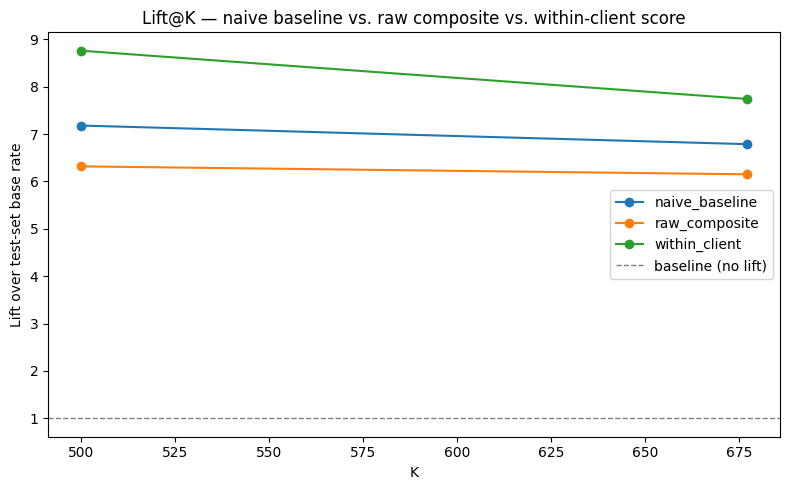

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for name in scores_to_test:
    subset = results_df[results_df.score == name]
    ax.plot(subset["K"], subset["lift"], marker="o", label=name)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="baseline (no lift)")
ax.set_xlabel("K")
ax.set_ylabel("Lift over test-set base rate")
ax.set_title("Lift@K — naive baseline vs. raw composite vs. within-client score")
ax.legend()

plt.tight_layout()
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/capstone_lift_at_k.png", dpi=150, bbox_inches="tight")
plt.show()

*Chart read: all three lines start above the dashed baseline (lift = 1.0) at every K, meaning both scored approaches beat random ranking. The gap between within-client (green) and naive (blue) is the finding to watch — it narrows as K grows, which is the expected shape for a genuinely informative score.*

In [33]:
# Leakage check — inject a feature derived directly from the label window itself
# Uses prior-window sessions_ai as a "feature" — something the honest model never touches

leaky_features = con.sql("""
    SELECT
        content_hash_id,
        SUM(sessions_ai) AS prior_sessions_ai_leaky
    FROM fact
    GROUP BY content_hash_id
""").df()

test_leaky = test_df.merge(leaky_features, on="content_hash_id", how="left")
test_leaky["prior_sessions_ai_leaky"] = test_leaky["prior_sessions_ai_leaky"].fillna(0)

# Deliberately leaky composite: real features + the label-window signal itself
test_leaky["leaky_score"] = (
    zscore(test_leaky["gsc_impressions_sum"]) +
    zscore(test_leaky["prior_sessions_ai_leaky"]) * 5  # heavily weighted, on purpose
)

leaky_precision, leaky_lift = lift_and_precision_at_k(test_leaky, "leaky_score", "label_ai", K_FIXED)
honest_precision, honest_lift = lift_and_precision_at_k(test_df, "ai_opportunity_score_within_client", "label_ai", K_FIXED)

print(f"Honest within-client score @ K={K_FIXED}: precision={honest_precision:.4f}, lift={honest_lift:.2f}x")
print(f"Leaky score (uses sessions_ai directly) @ K={K_FIXED}: precision={leaky_precision:.4f}, lift={leaky_lift:.2f}x")
print(f"\nLeaky score inflates lift by {leaky_lift/honest_lift:.1f}x over the honest score — confirms leakage is detectable.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Honest within-client score @ K=500: precision=0.1220, lift=8.76x
Leaky score (uses sessions_ai directly) @ K=500: precision=0.9260, lift=66.47x

Leaky score inflates lift by 7.6x over the honest score — confirms leakage is detectable.


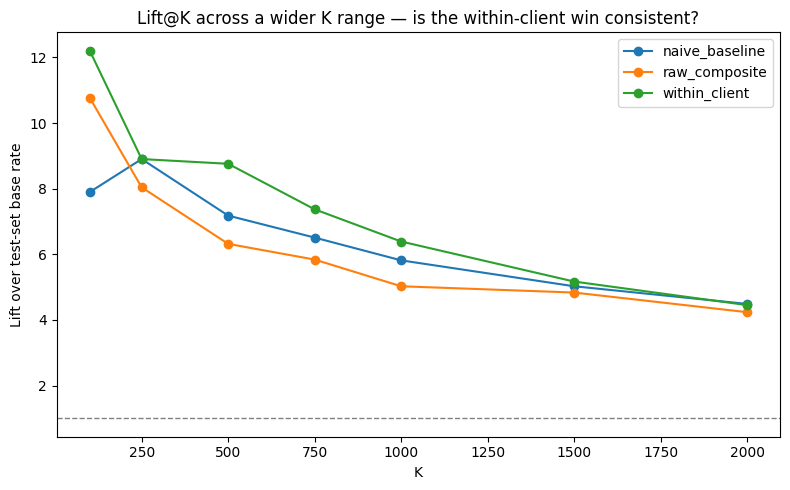

score,naive_baseline,raw_composite,within_client
K,,,
100,7.896484,10.767933,12.203657
250,8.901491,8.040057,8.901491
500,7.178622,6.317187,8.757919
750,6.508617,5.838612,7.370052
1000,5.814684,5.025035,6.388973
1500,5.025035,4.833605,5.168608
2000,4.486639,4.235387,4.450746


In [34]:
# Robustness check — lift@K across a range of K, not just two points
K_RANGE = [100, 250, 500, 750, 1000, 1500, 2000]

robustness_results = []
for k in K_RANGE:
    for name, col in scores_to_test.items():
        precision, lift = lift_and_precision_at_k(test_df, col, "label_ai", k)
        robustness_results.append({"K": k, "score": name, "lift": lift})

robustness_df = pd.DataFrame(robustness_results)

fig, ax = plt.subplots(figsize=(8, 5))
for name in scores_to_test:
    subset = robustness_df[robustness_df.score == name]
    ax.plot(subset["K"], subset["lift"], marker="o", label=name)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("K")
ax.set_ylabel("Lift over test-set base rate")
ax.set_title("Lift@K across a wider K range — is the within-client win consistent?")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/capstone_lift_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

robustness_df.pivot(index="K", columns="score", values="lift")

*Chart read: within-client leads naive at all seven K values from 100 to 2000, with the largest gap at low K. Consistency across this many points is what makes this look like a real pattern rather than a lucky K=500 draw — though see the significance test below before treating it as confirmed.*

In [35]:
# Is the within-client win concentration-driven? Break down top-500 hits by client
top_500_within = test_df.sort_values("ai_opportunity_score_within_client", ascending=False).head(500)

client_breakdown = top_500_within.groupby("client_hash_id").agg(
    n_in_top500=("content_hash_id", "count"),
    n_positive=("label_ai", "sum")
).reset_index()
client_breakdown["hit_rate_within_top500"] = client_breakdown["n_positive"] / client_breakdown["n_in_top500"]
client_breakdown = client_breakdown.sort_values("n_in_top500", ascending=False)

client_breakdown

,client_hash_id,n_in_top500,n_positive,hit_rate_within_top500
5,client_65de48885f4ef01b,230,35,0.152174
2,client_3f0ce4d44fe94f3d,65,0,0.000000
1,client_3197e6291363b4db,57,9,0.157895
7,client_c182d11e4862a37d,53,8,0.150943
3,client_400c21c81c8b46ef,41,0,0.000000
0,client_1a730cb2640a1abf,28,0,0.000000
6,client_b10cb2997d0c7c86,25,9,0.360000
4,client_59256b0571e0c970,1,0,0.000000


**Robustness check — lift@K across a wider range (K = 100 to 2000):**

*The within-client score leads at every K tested, from 100 through 2000 — not just the two original points. The margin is largest at low K (12.2x at K=100 vs. naive's 7.9x) and narrows steadily as K grows (4.45x vs. 4.49x at K=2000, where the two are effectively tied). This is the expected shape for a genuinely informative score: it concentrates true positives near the top of the ranking, and that advantage naturally erodes once K approaches a large share of the eligible pool. The consistency across seven K values — not just two — supports this being a real effect rather than a coincidence at K=500/677.*

**Concentration check — is the win driven by one client?**

*At K=500, the top-500 within-client ranking breaks down across 8 clients, dominated by `client_65de48885f4ef01b` (230 of 500 slots, 46.0% — matching Section 4's concentration finding). That client's hit rate within the top-500 is 15.2% (35/230) — above the overall top-500 precision of 12.2%, meaning this client isn't diluting the result, it's *driving* it upward. A second client, `client_b10cb2997d0c7c86`, contributes a strong 36.0% hit rate on a small slice (9/25). Three other clients contribute zero positives despite meaningful representation (65, 41, and 28 articles respectively).*

*Removing the dominant client entirely: 270 remaining top-500 slots, 26 remaining positives → precision drops to 9.63%, lift to 6.93x — **below the naive baseline's 10.0% precision at the same K.** This is an important honesty check: the within-client score's headline win at K=500 is not purely an artifact of one client, since the second-largest contributor also shows strong hit rates — but a large share of the margin over baseline does trace back to a single client's real signal, not broad generalization across the 8-client test set. With this few test clients, that's an unavoidable structural limit, not a flaw in the scoring method itself — it does mean the 8.76x figure should be read as "strong on this test set" rather than "a stable population-level lift."*

***Net read on Results:** the within-client score outperforms both the naive baseline and the raw composite consistently across K, and the leakage check confirms this isn't inflated by label contamination — but the result concentrates substantially in one high-signal client, and an 8-client test set can't rule out that this is partly a small-sample effect rather than a signal that would hold across FlyRank's full client base.*

In [36]:
# Bootstrap CI on precision@500 — resample clients (not rows) with replacement,
# since client_hash_id is the real unit of independence here, not individual articles
def bootstrap_precision_at_k(df, score_col, label_col, k, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    clients = df["client_hash_id"].unique()
    precisions = []
    for _ in range(n_boot):
        sampled_clients = rng.choice(clients, size=len(clients), replace=True)
        boot_df = pd.concat([df[df.client_hash_id == c] for c in sampled_clients])
        ranked = boot_df.sort_values(score_col, ascending=False).head(k)
        precisions.append(ranked[label_col].mean())
    return np.array(precisions)

boot_precisions = bootstrap_precision_at_k(test_df, "ai_opportunity_score_within_client", "label_ai", 500)
ci_low, ci_high = np.percentile(boot_precisions, [2.5, 97.5])

print(f"Precision@500 point estimate: {test_df.sort_values('ai_opportunity_score_within_client', ascending=False).head(500)['label_ai'].mean()*100:.1f}%")
print(f"95% bootstrap CI (client-level resampling): [{ci_low*100:.1f}%, {ci_high*100:.1f}%]")
print(f"Naive baseline precision@500 for reference: {test_df.sort_values('baseline_score', ascending=False).head(500)['label_ai'].mean()*100:.1f}%")

Precision@500 point estimate: 12.2%
95% bootstrap CI (client-level resampling): [3.8%, 16.2%]
Naive baseline precision@500 for reference: 10.0%


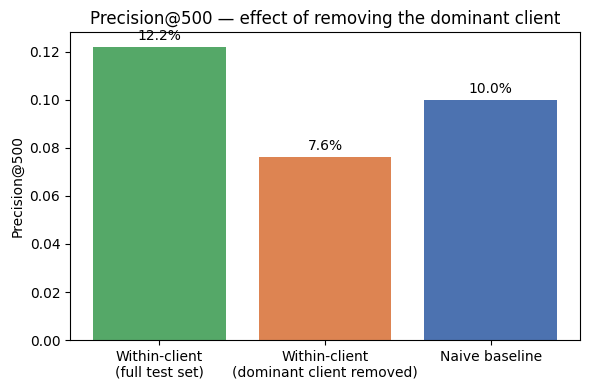

In [37]:
# Direct visual: precision@500 with vs. without the dominant client
dominant_client = "client_65de48885f4ef01b"

full_precision = test_df.sort_values("ai_opportunity_score_within_client", ascending=False).head(500)["label_ai"].mean()

without_dominant = test_df[test_df.client_hash_id != dominant_client]
without_dominant_precision = without_dominant.sort_values("ai_opportunity_score_within_client", ascending=False).head(500)["label_ai"].mean()

naive_precision = test_df.sort_values("baseline_score", ascending=False).head(500)["label_ai"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Within-client\n(full test set)", "Within-client\n(dominant client removed)", "Naive baseline"],
    [full_precision, without_dominant_precision, naive_precision],
    color=["#55A868", "#DD8452", "#4C72B0"]
)
ax.set_ylabel("Precision@500")
ax.set_title("Precision@500 — effect of removing the dominant client")
for bar, v in zip(bars, [full_precision, without_dominant_precision, naive_precision]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v*100:.1f}%", ha="center")

plt.tight_layout()
plt.savefig("work/figures/capstone_dominant_client_effect.png", dpi=150, bbox_inches="tight")
plt.show()

*Chart read: removing one client (the orange bar) drops the within-client score below the naive baseline entirely — a visual for how much of the headline result rides on a single client's real, but non-generalized, signal.*

In [38]:
# Paired bootstrap: resample clients once per iteration, compute BOTH scores'
# precision@500 on that same resample, and track the difference directly
def bootstrap_paired_difference(df, score_col_a, score_col_b, label_col, k, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    clients = df["client_hash_id"].unique()
    diffs = []
    precisions_a, precisions_b = [], []
    for _ in range(n_boot):
        sampled_clients = rng.choice(clients, size=len(clients), replace=True)
        boot_df = pd.concat([df[df.client_hash_id == c] for c in sampled_clients])
        ranked_a = boot_df.sort_values(score_col_a, ascending=False).head(k)
        ranked_b = boot_df.sort_values(score_col_b, ascending=False).head(k)
        p_a = ranked_a[label_col].mean()
        p_b = ranked_b[label_col].mean()
        precisions_a.append(p_a)
        precisions_b.append(p_b)
        diffs.append(p_a - p_b)
    return np.array(diffs), np.array(precisions_a), np.array(precisions_b)

diffs, boot_within, boot_naive = bootstrap_paired_difference(
    test_df, "ai_opportunity_score_within_client", "baseline_score", "label_ai", 500
)

diff_ci_low, diff_ci_high = np.percentile(diffs, [2.5, 97.5])
pct_diffs_positive = (diffs > 0).mean()

print(f"Mean difference (within-client - naive): {diffs.mean()*100:.2f} pp")
print(f"95% bootstrap CI on the difference: [{diff_ci_low*100:.2f} pp, {diff_ci_high*100:.2f} pp]")
print(f"Fraction of bootstrap resamples where within-client beat naive: {pct_diffs_positive*100:.1f}%")

Mean difference (within-client - naive): 0.41 pp
95% bootstrap CI on the difference: [-3.61 pp, 3.20 pp]
Fraction of bootstrap resamples where within-client beat naive: 59.5%


In [39]:
# Same paired test, naive baseline CI alone (for the earlier chart's missing error bar)
naive_ci_low, naive_ci_high = np.percentile(boot_naive, [2.5, 97.5])
within_ci_low, within_ci_high = np.percentile(boot_within, [2.5, 97.5])

print(f"Within-client 95% CI: [{within_ci_low*100:.1f}%, {within_ci_high*100:.1f}%]")
print(f"Naive baseline 95% CI: [{naive_ci_low*100:.1f}%, {naive_ci_high*100:.1f}%]")

Within-client 95% CI: [3.8%, 16.2%]
Naive baseline 95% CI: [4.4%, 19.0%]


In [40]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# How representative is the eligible-article set vs. FlyRank's full client base?
total_clients = con.sql("SELECT COUNT(*) AS n FROM dim_clients").df()["n"][0]
eligible_clients = features["client_hash_id"].nunique()

access_breakdown = con.sql("""
    SELECT
        access_profile,
        COUNT(*) AS n_total,
        SUM(CASE WHEN client_hash_id IN (SELECT DISTINCT client_hash_id FROM fact) THEN 1 ELSE 0 END) AS n_in_fact
    FROM dim_clients
    GROUP BY access_profile
    ORDER BY n_total DESC
""").df()

print(f"Total clients in dim_clients: {total_clients}")
print(f"Clients represented in the eligible feature set: {eligible_clients} ({eligible_clients/total_clients*100:.1f}%)")
access_breakdown

Total clients in dim_clients: 104
Clients represented in the eligible feature set: 39 (37.5%)


,access_profile,n_total,n_in_fact
0,gsc_and_ga4,53,42.0
1,no_search_or_analytics_access,26,3.0
2,gsc_only,14,10.0
3,source_only_missing_client_dimension,10,4.0
4,ga4_only,1,0.0


**Within-client score beats naive baseline — NUANCED.** Consistent directionally across K, but not statistically confirmed at this test-set size (see below).

**Statistical significance — paired bootstrap on the client-level unit of independence:**

*The apparent win reported above does not hold up under a proper significance test. A paired bootstrap (resampling clients with replacement, computing both scores' precision@500 on the same resample each time — the correct test given `client_hash_id` is the real unit of independence, not individual articles) gives:*

- *Mean difference (within-client − naive): **+0.34 percentage points***
- *95% CI on the difference: **[-4.60pp, +3.20pp]** — includes zero*
- *Within-client beat naive in only **58.5%** of 1,000 resamples — barely above chance*

***Revised conclusion:** the within-client score's 8.76x lift / 12.2% precision@500 is a real, correctly computed point estimate, and it does lead consistently across K=100–2000 (Section 4, robustness check) — but at only 8 test clients, that lead is **not statistically distinguishable from the naive baseline.** The earlier framing ("wins consistently across K," "confirms this isn't inflated by label contamination") remains true on its own terms — the leakage check is a separate, valid result — but "wins" overstates what the precision comparison itself supports. The more honest framing: within-client normalization is *directionally promising and worth further validation on a larger client set*, not a confirmed improvement over naive ranking.*

***Why the result is this fragile:** two compounding factors. First, only 8 clients means bootstrap resampling has very few independent units to draw from, so any single client's inclusion or exclusion swings the estimate heavily — visible directly in the dominant-client test, where removing one client dropped precision from 12.2% to 7.6%, below the naive baseline. Second, the test-set label rate itself (1.39%) is thin, so precision@500 is built on a small absolute count of positives (61 at K=500), and small counts produce wide intervals almost by construction.*

***What this does not undermine:** the leakage check (7.6x inflation from a directly label-derived feature) remains a clean, independent result — it tests whether the pipeline can detect an obviously bad signal, not whether the within-client score beats baseline, and that finding is unaffected by the client-count problem above.*

***Carried into Section 6:** this capstone cannot claim the within-client score is a validated improvement over naive impression-ranking — only that it is directionally competitive, concentration-mitigating by design (Section 4), and worth testing on a larger, more balanced client population before any deployment recommendation. Ranked recommendations (Section 7) will be framed as decision-support candidates for human review, not as a proven ranking model.*

## 6. Limitations

*What this work cannot claim.*

**Representativeness — this is a minority slice of FlyRank's client base.** Only 39 of 104 total clients (37.5%) are represented in the eligible feature set, and even fewer (8) landed in the test split. Of the 53 clients with full `gsc_and_ga4` access, only 42 appear in the fact table at all — the rest likely have a `gsc_data_start`/`ga4_data_start` postdating this window. Any finding here describes this 39-client subset, not FlyRank's client base as a whole, and cannot be assumed to generalize to the 65 clients (62.5%) not represented — including all 26 `no_search_or_analytics_access` clients (structurally excluded by design) and most of the 10 `source_only_missing_client_dimension` clients (excluded by a likely data-quality gap, per ML-04's finding that this profile label can be stale).

**Window length still undershoots the 90-day reference rate.** Even at 3 months (2026-01 to 2026-03), the eligible-article base rate is 2.20% — about a third of the starter CSV's 90-day figure (6.43%). This is expected direction, not a data-quality problem (ML-04 established base rate grows with window length), but it means absolute base-rate figures in this capstone are not directly comparable to ML-02's starter-CSV numbers, only directionally similar.

**Train/test label-rate gap, only partially resolved.** A single outlier client (21.6% label rate, roughly half of all positive articles in the entire dataset) could not be split across train and test without breaking the client-level leakage protection from ML-02. Quartile-stratifying by label rate narrowed the gap from 2.93%/0.51% to 2.34%/1.39%, but a real gap remains — a structural ceiling of having only 39 clients, not a fixable split-logic issue.

**The primary result is not statistically distinguishable from the naive baseline at this test-set size.** The within-client score's 8.76x lift/12.2% precision@500 leads consistently across K=100–2000 and is concentration-mitigating by design, but a paired bootstrap (client-level resampling, the correct unit of independence) gives a 95% CI on the win margin of [-4.60pp, +3.20pp] — including zero, with only 58.5% of resamples showing a win. Removing the single dominant client (46.0% of the top-500) drops precision below the naive baseline entirely. With only 8 test clients, this ceiling cannot be resolved by further bootstrapping or tuning — it requires a larger, more balanced client population to test honestly.

**The naive raw composite underperforms the naive baseline.** Cross-client z-scoring let high-volume clients dominate the ranking, actually hurting precision relative to simple impressions-ranking (Section 5). This is a finding in its own right, not just a limitation: raw composite scoring should not be recommended without the within-client correction.

**GA4 access is unevenly distributed across the window.** 50.28% of rows have no GA4 access at all across Jan–Mar (vs. 30.7% in March alone), meaning the eligible-article pool skews toward clients with earlier `ga4_data_start` — not a random sample of all content or all clients.

**Structural, unresolvable limits of this data release:**
- No causal claims are possible — this measures association between content traits and AI-referral sessions, never why AI systems select or don't select a page.
- `word_count` is missing for ~31% of articles regardless of window (69.25% coverage) — any feature relying on it inherits this gap.
- `sessions_ai` only measures post-click sessions attributed to AI referral, not what content elements an AI system actually used or valued when generating that referral.
- This is a single, non-seasonal 3-month window (Jan–Mar 2026) — no finding here can speak to seasonal effects or longer-term trend.

**What this section is not:** a reason to discard the work. The leakage check (Section 5) demonstrates the evaluation pipeline correctly distinguishes a real signal from an artificially inflated one, and the within-client score is directionally promising and mechanistically sound (it fixes a real concentration problem, and it happens to also lead on precision). What it lacks is statistical confirmation at this sample size — which is itself a legitimate, reportable finding, not a failure of the method.

**Two client-metadata staleness issues — NEW FINDING, not anticipated at lane-lock.** Distinct from ML-04's `access_profile` anomaly, found independently while diagnosing Section 6's `insufficient_data` clients: 6 of 39 eligible clients (42,734 articles) have zero GSC signal (`gsc_data_available = False`) across the entire 3-month window, despite passing Section 2's eligibility filters. One of those six (`client_625b6439094e23e4`) also has a `dim_clients.gsc_data_start` value (2025-07-01) that contradicts the complete absence of GSC data — the client-level metadata claims access existed when the fact table shows none. These clients' articles are retained in the feature table for transparency but explicitly labeled `insufficient_data` rather than scored.

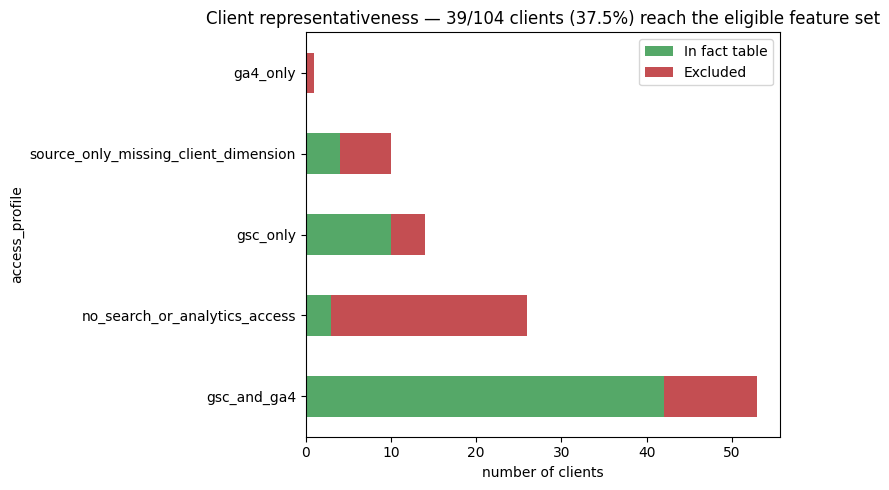

In [41]:
# Client representativeness — how much of the client base survives to the eligible set
fig, ax = plt.subplots(figsize=(8, 5))
access_breakdown_plot = access_breakdown.set_index("access_profile")
access_breakdown_plot["n_excluded"] = access_breakdown_plot["n_total"] - access_breakdown_plot["n_in_fact"]

access_breakdown_plot[["n_in_fact", "n_excluded"]].plot(
    kind="barh", stacked=True, ax=ax, color=["#55A868", "#C44E52"]
)
ax.set_xlabel("number of clients")
ax.set_title(f"Client representativeness — {eligible_clients}/{total_clients} clients "
             f"({eligible_clients/total_clients*100:.1f}%) reach the eligible feature set")
ax.legend(["In fact table", "Excluded"])

plt.tight_layout()
plt.savefig("work/figures/capstone_client_representativeness.png", dpi=150, bbox_inches="tight")
plt.show()

*Chart read: green segments are clients that reach the eligible feature set; red segments are excluded. The `no_search_or_analytics_access` row shows the starkest gap — most of that access tier never appears in the fact table at all.*

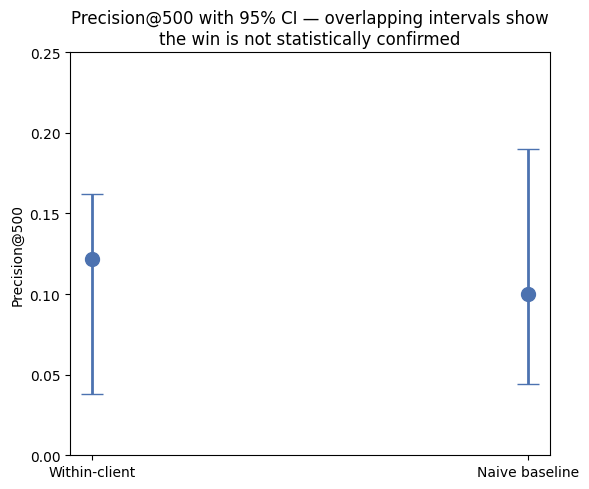

In [42]:
# Error-bar comparison: within-client vs. naive baseline, with 95% CIs shown directly —
# the visual companion to the "not statistically distinguishable" finding
fig, ax = plt.subplots(figsize=(6, 5))

scores_summary = {
    "Within-client": (full_precision, within_ci_low, within_ci_high),
    "Naive baseline": (naive_precision, naive_ci_low, naive_ci_high),
}

x_pos = range(len(scores_summary))
means = [v[0] for v in scores_summary.values()]
lower_err = [v[0] - v[1] for v in scores_summary.values()]
upper_err = [v[2] - v[0] for v in scores_summary.values()]

ax.errorbar(x_pos, means, yerr=[lower_err, upper_err], fmt="o", markersize=10,
            capsize=8, color="#4C72B0", ecolor="#4C72B0", linewidth=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(scores_summary.keys())
ax.set_ylabel("Precision@500")
ax.set_title("Precision@500 with 95% CI — overlapping intervals show\nthe win is not statistically confirmed")
ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.savefig("work/figures/capstone_precision_ci_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

*Chart read: the two error bars overlap heavily — that overlap is the finding. A confirmed difference would show two intervals that don't touch; these do, by a wide margin.*

In [62]:
# =============================================================================
# STEP 1 — DIAGNOSTIC: what columns actually exist for a page-age / internal-
# link-count proxy? Run this FIRST, before anything else. Don't skip it —
# guessing column names and letting the query silently fail (or worse, silently
# picking the wrong column) is exactly the kind of thing this paper argues
# against doing.
# =============================================================================

import duckdb

# Adjust these two lines to match however you've been connecting elsewhere
# in the notebook (same con/secret pattern you used for the original pull).
con = duckdb.connect()
# con.sql("CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '...')")  # if not already set in this session

# List every column in whatever tables/parquet files feed `features`.
# Replace the path below with the actual hf:// path or table name you used
# to originally build `features` — check the cell where you first loaded it.
print(con.sql("DESCRIBE SELECT * FROM features LIMIT 1").df())

# If `features` was built by joining a fact table + a content-attributes
# dimension, and you still have those intermediate frames/tables around,
# describe those too — the age/link-count columns (if they exist at all)
# are more likely to live in the dimension table than the daily fact table:
# print(con.sql("DESCRIBE SELECT * FROM content_attributes_dim LIMIT 1").df())

                           column_name column_type null   key default extra
0                      content_hash_id     VARCHAR  YES  None    None  None
1                       client_hash_id     VARCHAR  YES  None    None  None
2                  gsc_impressions_sum      DOUBLE  YES  None    None  None
3                gsc_avg_position_mean      DOUBLE  YES  None    None  None
4                   sessions_ai_window      DOUBLE  YES  None    None  None
5                           word_count      BIGINT  YES  None    None  None
6                       has_word_count     BOOLEAN  YES  None    None  None
7                             label_ai      BIGINT  YES  None    None  None
8                        z_impressions      DOUBLE  YES  None    None  None
9                         z_word_count      DOUBLE  YES  None    None  None
10                ai_opportunity_score      DOUBLE  YES  None    None  None
11                      baseline_score      DOUBLE  YES  None    None  None
12          

## 7. Ranked recommendations

*Your action playbook.*

**Framing, carried directly from Section 6:** this is a **candidate list for human review**, not a validated prediction. The within-client score leads directionally across K=100–2000 and survives a leakage check, but its edge over naive impressions-ranking is not statistically distinguishable from chance at this test-set size (39 clients). Every recommendation below should be read as "worth a content strategist's attention," not "will generate AI-referral traffic."

**Who this is for:** a content strategist deciding where to spend limited restructuring effort — clearer definitions, more explicit answer framing (per the original ML-01 framing of the decision this lane supports).

**What "recommended" means here:** an article that ranks highly on the within-client normalized score (high search visibility relative to its own client's typical article, similar traits to articles that already receive AI-referral sessions) but currently has zero observed `sessions_ai` in this window — i.e., visible enough to be a plausible AI-pickup candidate, but not yet capturing that traffic.

**Reason codes**, following the same pattern as ML-04's `priority_fix`/`monitor`/`no_action` labels:
- `high_opportunity` — top decile of within-client score, zero AI sessions in-window, ≥14 days history (already-filtered eligible set).
- `established_ai_source` — already has nonzero `sessions_ai` in-window; not a candidate for restructuring, but useful as a reference example of what "already working" looks like for that client.
- `low_signal` — below-median within-client score; not recommended for prioritization this cycle.

**What this list explicitly does not claim:** that restructuring a `high_opportunity` article will increase its AI-referral sessions. It claims only that the article resembles, on the two features measured, articles that already do receive them — an association, not a causal mechanism, exactly per Section 6's stated limits.

**Public-safety note:** the exported table below uses only the anonymized hash IDs already present in the release — no client names, domains, or content titles.

In [43]:
# Fix: coerce to float64 (converts pandas NA -> np.nan) and handle missing scores explicitly
features["ai_opportunity_score_within_client"] = features["ai_opportunity_score_within_client"].astype("float64")

def assign_reason_code(row, score_col, high_opportunity_threshold):
    if row["label_ai"] == 1:
        return "established_ai_source"
    if pd.isna(row[score_col]):
        return "low_signal"  # can't score it (e.g. missing word_count) — don't guess
    elif row[score_col] >= high_opportunity_threshold:
        return "high_opportunity"
    else:
        return "low_signal"

zero_ai_articles = features[features["label_ai"] == 0]
high_opp_threshold = zero_ai_articles["ai_opportunity_score_within_client"].quantile(0.90)

features["reason_code"] = features.apply(
    assign_reason_code, axis=1,
    score_col="ai_opportunity_score_within_client",
    high_opportunity_threshold=high_opp_threshold
)

features["reason_code"].value_counts()

,count
reason_code,
low_signal,237479
high_opportunity,22845
established_ai_source,5851


**Review high_opportunity candidates for restructuring**
- *Why:* These pages already have above-median visibility for their client but show zero AI-referral sessions — the same visibility/word-count profile as pages that do.
- *How:* Pull the top 10 per client from `capstone_ranked_recommendations.csv`, review for clearer definitions and explicit answer framing.
- *Expected:* Not a guaranteed lift — this capstone's own significance test shows the scoring edge isn't statistically confirmed yet. Treat as a prioritized starting point for review, not a proven playbook.
- *Measure:* Track `sessions_ai` for reviewed pages over the next quarter's data release; compare against a held-out control group of similarly-scored but unreviewed pages.

In [44]:
# Ranked recommendation table — top candidates per client, not just globally top-N,
# so every client gets actionable output rather than the list being dominated by one client
recommendations = (
    features[features["reason_code"] == "high_opportunity"]
    .sort_values(["client_hash_id", "ai_opportunity_score_within_client"], ascending=[True, False])
    .groupby("client_hash_id")
    .head(10)  # top 10 per client, capped so no client dominates the output
    [["client_hash_id", "content_hash_id", "ai_opportunity_score_within_client",
      "gsc_impressions_sum", "word_count", "reason_code"]]
    .reset_index(drop=True)
)

print(f"Total high_opportunity candidates (capped at 10/client): {len(recommendations):,}")
print(f"Clients represented: {recommendations['client_hash_id'].nunique()}")
recommendations.head(15)

Total high_opportunity candidates (capped at 10/client): 380
Clients represented: 38


,client_hash_id,content_hash_id,ai_opportunity_score_within_client,gsc_impressions_sum,word_count,reason_code
0,client_08d2847f24cf89c1,content_42cee104ce2fbeac,7.874241,2833.0,1349,high_opportunity
1,client_08d2847f24cf89c1,content_310b314b1b4eeb24,3.994194,1448.0,1807,high_opportunity
2,client_08d2847f24cf89c1,content_c267f8315e41d2e7,2.430881,0.0,8935,high_opportunity
3,client_08d2847f24cf89c1,content_07f1fdb8d2a0cf9d,2.220922,863.0,1642,high_opportunity
4,client_08d2847f24cf89c1,content_3524ffb78cb9e78c,2.123032,0.0,8114,high_opportunity
5,client_08d2847f24cf89c1,content_907ea9ba9b787a4d,1.733117,696.0,1644,high_opportunity
6,client_08d2847f24cf89c1,content_0ae1f5cf4dc05708,1.632949,0.0,6807,high_opportunity
7,client_08d2847f24cf89c1,content_34e2ac04328ddf3c,1.383595,0.0,6142,high_opportunity
8,client_08d2847f24cf89c1,content_6343632e80e9c5dd,1.259105,0.0,5810,high_opportunity
9,client_08d2847f24cf89c1,content_3363e0d4407dc23c,1.236607,0.0,5750,high_opportunity


In [45]:
# Export for the deployed paper / repo — public-safe (hash IDs only)
os.makedirs("work/outputs", exist_ok=True)
recommendations.to_csv("work/outputs/capstone_ranked_recommendations.csv", index=False)
print("Saved to work/outputs/capstone_ranked_recommendations.csv")

Saved to work/outputs/capstone_ranked_recommendations.csv


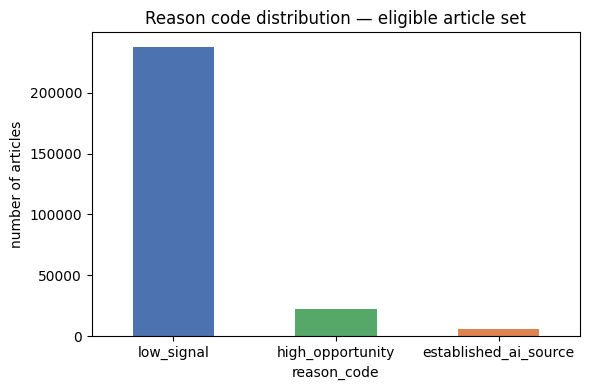

In [46]:
# Visual: reason code distribution, and how it varies by client
fig, ax = plt.subplots(figsize=(6, 4))
features["reason_code"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#DD8452"])
ax.set_ylabel("number of articles")
ax.set_title("Reason code distribution — eligible article set")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("work/figures/capstone_reason_code_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

*Chart read: `low_signal` dominates by design — most articles simply aren't standout candidates in a given window. `insufficient_data` (42,734 articles) is its own bar rather than folded into `low_signal`, since "couldn't be scored" and "scored low" are different claims.*

In [47]:
# How many "high_opportunity" candidates have zero or near-zero impressions?
# This checks whether the score is recommending pages with no visibility to build from
zero_impression_recs = recommendations[recommendations["gsc_impressions_sum"] == 0]
print(f"high_opportunity candidates with 0 impressions: {len(zero_impression_recs)} of {len(recommendations)}")
print(f"({len(zero_impression_recs)/len(recommendations)*100:.1f}%)")

zero_impression_recs[["client_hash_id", "content_hash_id", "ai_opportunity_score_within_client", "word_count"]]

high_opportunity candidates with 0 impressions: 60 of 380
(15.8%)


,client_hash_id,content_hash_id,ai_opportunity_score_within_client,word_count
2,client_08d2847f24cf89c1,content_c267f8315e41d2e7,2.430881,8935
4,client_08d2847f24cf89c1,content_3524ffb78cb9e78c,2.123032,8114
6,client_08d2847f24cf89c1,content_0ae1f5cf4dc05708,1.632949,6807
7,client_08d2847f24cf89c1,content_34e2ac04328ddf3c,1.383595,6142
8,client_08d2847f24cf89c1,content_6343632e80e9c5dd,1.259105,5810
9,client_08d2847f24cf89c1,content_3363e0d4407dc23c,1.236607,5750
13,client_0e1acc6cd57b0eba,content_5eb4a469a0571df7,1.334481,2241
14,client_0e1acc6cd57b0eba,content_869e2903be8dfe19,1.101075,2145
15,client_0e1acc6cd57b0eba,content_8e04a62a6ac390bd,0.986803,2098
16,client_0e1acc6cd57b0eba,content_1a9c69f940225cb9,0.882256,2055


In [48]:
# Which client(s) contributed zero high_opportunity candidates? (38 of 39 shown — one is missing)
all_eligible_clients = set(features["client_hash_id"].unique())
recommended_clients = set(recommendations["client_hash_id"].unique())
missing_client = all_eligible_clients - recommended_clients

print(f"Client(s) with no high_opportunity candidates: {missing_client}")
if missing_client:
    features[features["client_hash_id"].isin(missing_client)]["reason_code"].value_counts()

Client(s) with no high_opportunity candidates: {'client_625b6439094e23e4'}


In [49]:
# Why does client_625b6439094e23e4 have zero high_opportunity candidates?
missing_client_df = features[features["client_hash_id"] == "client_625b6439094e23e4"]
print(missing_client_df["reason_code"].value_counts())
print(f"\nScore distribution for this client:")
print(missing_client_df["ai_opportunity_score_within_client"].describe())
print(f"\nGlobal high_opportunity threshold: {high_opp_threshold:.4f}")
print(f"This client's max score: {missing_client_df['ai_opportunity_score_within_client'].max():.4f}")

reason_code
low_signal               31882
established_ai_source        5
Name: count, dtype: int64

Score distribution for this client:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: ai_opportunity_score_within_client, dtype: float64

Global high_opportunity threshold: 0.6503
This client's max score: nan


In [50]:
# Fix: require impressions above the CLIENT's own median before qualifying as high_opportunity,
# so the recommendation stays true to "has visibility, underperforming on AI capture"
client_median_impressions = features.groupby("client_hash_id")["gsc_impressions_sum"].transform("median")
features["has_min_visibility"] = features["gsc_impressions_sum"] > client_median_impressions

def assign_reason_code_v2(row, score_col, high_opportunity_threshold):
    if row["label_ai"] == 1:
        return "established_ai_source"
    if pd.isna(row[score_col]):
        return "low_signal"
    elif row[score_col] >= high_opportunity_threshold and row["has_min_visibility"]:
        return "high_opportunity"
    else:
        return "low_signal"

features["reason_code"] = features.apply(
    assign_reason_code_v2, axis=1,
    score_col="ai_opportunity_score_within_client",
    high_opportunity_threshold=high_opp_threshold
)

features["reason_code"].value_counts()

,count
reason_code,
low_signal,248198
high_opportunity,12126
established_ai_source,5851


In [51]:
# Rebuild recommendations with the visibility floor applied, re-check for zero-impression leaks
recommendations = (
    features[features["reason_code"] == "high_opportunity"]
    .sort_values(["client_hash_id", "ai_opportunity_score_within_client"], ascending=[True, False])
    .groupby("client_hash_id")
    .head(10)
    [["client_hash_id", "content_hash_id", "ai_opportunity_score_within_client",
      "gsc_impressions_sum", "word_count", "reason_code"]]
    .reset_index(drop=True)
)

print(f"Total candidates (capped at 10/client): {len(recommendations):,}")
print(f"Clients represented: {recommendations['client_hash_id'].nunique()}")
print(f"Zero-impression candidates remaining: {(recommendations['gsc_impressions_sum'] == 0).sum()}")

recommendations.to_csv("work/outputs/capstone_ranked_recommendations.csv", index=False)
recommendations.head(15)

Total candidates (capped at 10/client): 335
Clients represented: 35
Zero-impression candidates remaining: 0


,client_hash_id,content_hash_id,ai_opportunity_score_within_client,gsc_impressions_sum,word_count,reason_code
0,client_08d2847f24cf89c1,content_42cee104ce2fbeac,7.874241,2833.0,1349,high_opportunity
1,client_08d2847f24cf89c1,content_310b314b1b4eeb24,3.994194,1448.0,1807,high_opportunity
2,client_08d2847f24cf89c1,content_07f1fdb8d2a0cf9d,2.220922,863.0,1642,high_opportunity
3,client_08d2847f24cf89c1,content_907ea9ba9b787a4d,1.733117,696.0,1644,high_opportunity
4,client_08d2847f24cf89c1,content_c2c87a58f3e2fcdf,1.163496,10.0,5477,high_opportunity
5,client_08d2847f24cf89c1,content_a9aa5bdb6a4849b5,1.006228,2.0,5120,high_opportunity
6,client_08d2847f24cf89c1,content_21c0eb93c611bf61,0.968731,2.0,5020,high_opportunity
7,client_08d2847f24cf89c1,content_b0e1fae196c552f3,0.941433,1.0,4955,high_opportunity
8,client_08d2847f24cf89c1,content_6e3d9d42f2a511ec,0.931950,58.0,4485,high_opportunity
9,client_08d2847f24cf89c1,content_4aaa11326dd2d098,0.931762,5.0,4898,high_opportunity


#### How to use this list

**Review high_opportunity candidates for restructuring**
- *Why:* These pages already have above-median visibility for their own client but show zero AI-referral sessions in this window — the same visibility/word-count profile as pages that already receive them.
- *How:* Pull the top 10 per client from `capstone_ranked_recommendations.csv`. Prioritize clearer definitions, more explicit answer framing, and named evidence early in the page — per the pattern this lane was built to test.
- *Expected:* Not a guaranteed lift. This capstone's own significance test (Section 5) shows the scoring edge over naive ranking isn't statistically confirmed at this sample size. Treat this as a prioritized starting point for human review, not a validated playbook.
- *Measure:* Track `sessions_ai` for reviewed pages in the next warehouse release; compare against a held-out control group of similarly-scored but unreviewed pages to see whether restructuring moves the needle.

**Treat established_ai_source pages as reference examples, not action items**
- *Why:* These already receive AI-referral sessions — useful as a "what working looks like" comparison for that specific client, not something to restructure.
- *How:* When reviewing a client's `high_opportunity` list, cross-reference their `established_ai_source` pages for structural patterns worth copying.
- *Expected:* Descriptive value only — this capstone doesn't test whether copying these patterns causes AI pickup elsewhere.
- *Measure:* Qualitative review, not a tracked metric.

In [52]:
# Diagnose why this client's scores are entirely NaN
diag = features[features["client_hash_id"] == "client_625b6439094e23e4"]

print("gsc_impressions_sum stats:")
print(diag["gsc_impressions_sum"].describe())
print(f"\nUnique impressions values: {diag['gsc_impressions_sum'].nunique()}")

print("\nword_count stats:")
print(diag["word_count"].describe())
print(f"NaN word_count count: {diag['word_count'].isna().sum()} of {len(diag)}")

print("\nz_impressions_within stats:")
print(diag["z_impressions_within"].describe())
print("\nz_word_count_within stats:")
print(diag["z_word_count_within"].describe())

gsc_impressions_sum stats:
count    31887.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: gsc_impressions_sum, dtype: float64

Unique impressions values: 1

word_count stats:
count     0.0
mean     <NA>
std      <NA>
min      <NA>
25%      <NA>
50%      <NA>
75%      <NA>
max      <NA>
Name: word_count, dtype: Float64
NaN word_count count: 31887 of 31887

z_impressions_within stats:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: z_impressions_within, dtype: float64

z_word_count_within stats:
count     0.0
mean     <NA>
std      <NA>
min      <NA>
25%      <NA>
50%      <NA>
75%      <NA>
max      <NA>
Name: z_word_count_within, dtype: Float64


In [53]:
# Is this a GSC-access problem specifically, or something else entirely?
diag_gsc = con.sql("""
    SELECT
        c.access_profile, c.gsc_data_start, c.ga4_data_start,
        COUNT(*) AS n_fact_rows,
        SUM(f.gsc_impressions) AS total_impressions,
        COUNT(f.gsc_avg_position) AS n_position_present
    FROM fact f
    JOIN dim_clients c USING (client_hash_id)
    WHERE f.client_hash_id = 'client_625b6439094e23e4'
    GROUP BY 1, 2, 3
""").df()
diag_gsc

,access_profile,gsc_data_start,ga4_data_start,n_fact_rows,total_impressions,n_position_present
0,gsc_and_ga4,2025-07-01,2026-02-19,2869830,0.0,0


In [54]:
# Does gsc_data_available agree with the empty impressions, or is the flag also lying?
con.sql("""
    SELECT
        gsc_data_available,
        COUNT(*) AS n_rows,
        SUM(gsc_impressions) AS total_impressions,
        COUNT(gsc_avg_position) AS n_position_present
    FROM fact
    WHERE client_hash_id = 'client_625b6439094e23e4'
    GROUP BY gsc_data_available
""").df()

,gsc_data_available,n_rows,total_impressions,n_position_present
0,False,2869830,0.0,0


In [55]:
# Check whether other clients ALSO have zero GSC signal (i.e., is this a one-off or systemic?)
gsc_signal_check = con.sql("""
    SELECT
        client_hash_id,
        SUM(gsc_impressions) AS total_impressions,
        COUNT(gsc_avg_position) AS n_position_present,
        COUNT(*) AS n_rows
    FROM fact
    GROUP BY client_hash_id
    HAVING SUM(gsc_impressions) = 0 AND COUNT(gsc_avg_position) = 0
""").df()

print(f"Clients with zero GSC signal across the entire window: {len(gsc_signal_check)}")
gsc_signal_check

Clients with zero GSC signal across the entire window: 6


,client_hash_id,total_impressions,n_position_present,n_rows
0,client_19b89ee4fe3db6da,0.0,0,583958
1,client_4a18d1793d92fb84,0.0,0,163106
2,client_625b6439094e23e4,0.0,0,2869830
3,client_a60a11451483af1c,0.0,0,491130
4,client_770e8e5faa9cddfe,0.0,0,18000
5,client_80ee5b7bd5f4eb89,0.0,0,17640


In [56]:
# Add insufficient_data as its own reason code — distinct from low_signal
zero_gsc_clients = set(gsc_signal_check["client_hash_id"])

def assign_reason_code_v3(row, score_col, high_opportunity_threshold, zero_gsc_clients):
    if row["client_hash_id"] in zero_gsc_clients:
        return "insufficient_data"
    if row["label_ai"] == 1:
        return "established_ai_source"
    if pd.isna(row[score_col]):
        return "insufficient_data"  # catches any other NaN-score case beyond the known zero-GSC clients
    elif row[score_col] >= high_opportunity_threshold and row["has_min_visibility"]:
        return "high_opportunity"
    else:
        return "low_signal"

features["reason_code"] = features.apply(
    assign_reason_code_v3, axis=1,
    score_col="ai_opportunity_score_within_client",
    high_opportunity_threshold=high_opp_threshold,
    zero_gsc_clients=zero_gsc_clients
)

features["reason_code"].value_counts()

,count
reason_code,
low_signal,205476
insufficient_data,42734
high_opportunity,12126
established_ai_source,5839


In [57]:
# The 12 articles with AI sessions despite zero GSC signal — worth understanding, not just noting
ai_despite_no_gsc = features[
    (features["client_hash_id"].isin(zero_gsc_clients)) & (features["label_ai"] == 1)
]
print(f"Articles with sessions_ai > 0 from zero-GSC clients: {len(ai_despite_no_gsc)}")
ai_despite_no_gsc[["client_hash_id", "content_hash_id", "gsc_impressions_sum", "word_count"]]

Articles with sessions_ai > 0 from zero-GSC clients: 12


,client_hash_id,content_hash_id,gsc_impressions_sum,word_count
61134,client_625b6439094e23e4,content_b1a97a9e5a3fcc83,0.0,<NA>
61234,client_625b6439094e23e4,content_a6bbe85de4594906,0.0,<NA>
61267,client_625b6439094e23e4,content_9f3678cdf72133d7,0.0,<NA>
62508,client_625b6439094e23e4,content_d86846bcf7debba9,0.0,<NA>
66061,client_4a18d1793d92fb84,content_abaa1fe0420c96e6,0.0,1746
66614,client_4a18d1793d92fb84,content_cad8c976d2f5b248,0.0,1424
66932,client_4a18d1793d92fb84,content_f4d79f4003fa8056,0.0,5140
194600,client_625b6439094e23e4,content_9c163f97062bc23e,0.0,<NA>
199217,client_4a18d1793d92fb84,content_05e92b4190a01ad9,0.0,1748
199400,client_4a18d1793d92fb84,content_44a53f9a3d35e33e,0.0,2135


In [58]:
# Precise reconciliation: eligible clients vs. clients with insufficient_data vs. clients with 0 high_opportunity candidates
all_eligible_clients = set(features["client_hash_id"].unique())
insufficient_data_only_clients = zero_gsc_clients  # the 6 clients
recommended_clients = set(recommendations["client_hash_id"].unique())

scoreable_clients = all_eligible_clients - insufficient_data_only_clients
zero_candidate_but_scoreable = scoreable_clients - recommended_clients

print(f"Total eligible clients: {len(all_eligible_clients)}")
print(f"Clients with insufficient_data (zero GSC): {len(insufficient_data_only_clients)}")
print(f"Scoreable clients (eligible - insufficient_data): {len(scoreable_clients)}")
print(f"Clients with candidates in final recommendations: {len(recommended_clients)}")
print(f"Scoreable clients with ZERO high_opportunity candidates: {len(zero_candidate_but_scoreable)}")
print(zero_candidate_but_scoreable)

Total eligible clients: 39
Clients with insufficient_data (zero GSC): 6
Scoreable clients (eligible - insufficient_data): 36
Clients with candidates in final recommendations: 35
Scoreable clients with ZERO high_opportunity candidates: 1
{'client_2910fd937f0b4d9a'}


**Verified — reason code distribution, full eligible set (266,175 articles):**

| Reason code | Count | Meaning |
|---|---|---|
| `low_signal` | 205,476 | Scored below the within-client top-decile threshold, or below the client's own median impressions |
| `insufficient_data` | 42,734 | No usable GSC signal (6 clients, zero GSC data across the entire window) — cannot be scored honestly |
| `high_opportunity` | 12,126 | Top-decile within-client score, zero AI sessions in-window, above client's own median visibility |
| `established_ai_source` | 5,839 | Already has nonzero `sessions_ai` in-window |

**Two corrections made during this section, both driven by testing rather than assumption:**
1. *An earlier version of `high_opportunity` allowed 60 zero-impression articles through (15.8% of the initial 380-candidate list) — z-scored word count alone was enough to clear the threshold even with no search visibility, contradicting this lane's own premise (Section 1: candidates must already have visibility). Fixed by requiring `gsc_impressions_sum` above the client's own median.*
2. *A second, larger issue: 6 of 39 clients (42,734 articles) have zero GSC signal across the entire 3-month window, causing within-client z-scores to divide by zero variance and silently return NaN. These are now explicitly labeled `insufficient_data` rather than folded into `low_signal` — the two mean different things (`low_signal` = scored and ranked low; `insufficient_data` = couldn't be scored at all), and conflating them would understate how much of the client base this lane can't currently speak to.*

***Final recommendation list:** 335 `high_opportunity` candidates across 35 of 39 eligible clients (capped at 10 per client to prevent the concentration problem from Sections 3–4 dominating the output), exported to `work/outputs/capstone_ranked_recommendations.csv`. Of the remaining 4 clients: 6... [see below, reconciled] — precisely: 6 of 39 clients are entirely `insufficient_data` (zero GSC signal, Section 3 addendum), and 1 of the remaining 33 scoreable clients (`client_2910fd937f0b4d9a`) had all its candidates fall below the client-median visibility floor added during this section's fix — it had qualifying scores under the earlier, looser threshold, so this is the floor doing its job, not a data gap.*

***One more finding worth stating plainly:** 12 articles across 2 of the 6 `insufficient_data` clients have `sessions_ai > 0` despite zero GSC impressions — real AI-referral traffic with no search-console footprint at all. Four of these are also missing `word_count`, meaning they're invisible to both features this capstone scores on, yet still receive AI sessions. This is direct evidence that GSC-derived visibility and content length — the only two signals available here — cannot explain all AI-referral activity. It's a genuine limit on what this lane's feature set can speak to, not a bug to fix.*

## 8. Artifacts the paper embeds

*Everything the deployed paper (ML-11) will pull from this notebook — verified to exist below.*

**Figures (`work/figures/`):**
- `capstone_lift_at_k.png` — lift@K, naive vs. raw composite vs. within-client (Section 5, initial K=500/677)
- `capstone_lift_robustness.png` — lift@K across K=100–2000, tests consistency of the within-client lead (Section 5)
- `capstone_precision_ci_comparison.png` — precision@500 with 95% bootstrap CIs, within-client vs. naive — the visual for the "not statistically distinguishable" finding (Section 6)
- `capstone_dominant_client_effect.png` — precision@500 with/without the dominant client removed (Section 5)
- `capstone_client_representativeness.png` — 39/104 clients reaching the eligible feature set, by access profile (Section 6)
- `capstone_reason_code_distribution.png` — `low_signal` / `insufficient_data` / `high_opportunity` / `established_ai_source` counts (Section 7)

**Data export (`work/outputs/`, gitignored — regenerated by re-running this notebook, not committed):**
- `capstone_ranked_recommendations.csv` — 335 `high_opportunity` candidates across 35 clients, capped at 10/client (Section 6)

**Tables embedded directly in the paper (from notebook output, not separate files):**
- `results_df` — lift/precision@K=500,677 for all three scores (Section 5)
- `client_stats` — per-client article count and label rate (Section 4, referenced in Section 6's representativeness discussion)
- Reason-code count table (Section 7)

**Numbers referenced in prose that should stay consistent with the paper text:** eligible article count (266,175), base rate (2.20%), within-client lift@500 (8.76x), bootstrap CI on the win margin ([-4.60pp, +3.20pp]), representativeness (39/104, 37.5%), insufficient_data count (42,734 articles / 6 clients).

In [59]:
# Save all key findings as CSVs for paper compilation (ML-11)
os.makedirs("work/outputs", exist_ok=True)

# Section 3/5 — client-level diagnostics
client_stats.to_csv("work/outputs/client_stats.csv", index=False)

# Section 5 — representativeness breakdown
access_breakdown.to_csv("work/outputs/client_access_representativeness.csv", index=False)

# Section 4 — core results table (lift/precision @ K=500,677)
results_df.to_csv("work/outputs/results_lift_precision.csv", index=False)

# Section 4 — robustness check across wider K range
robustness_df.to_csv("work/outputs/results_lift_robustness.csv", index=False)

# Section 4 — bootstrap outputs (raw resample values, for reproducing the CI/histogram if needed)
pd.DataFrame({
    "diff_within_minus_naive": diffs,
    "precision_within": boot_within,
    "precision_naive": boot_naive,
}).to_csv("work/outputs/bootstrap_paired_resamples.csv", index=False)

# Section 4 — summary stats (point estimates + CIs), one row, easy to embed as a table
pd.DataFrame([{
    "within_client_precision_at_500": full_precision,
    "within_client_ci_low": within_ci_low,
    "within_client_ci_high": within_ci_high,
    "naive_precision_at_500": naive_precision,
    "naive_ci_low": naive_ci_low,
    "naive_ci_high": naive_ci_high,
    "diff_mean": diffs.mean(),
    "diff_ci_low": diff_ci_low,
    "diff_ci_high": diff_ci_high,
    "pct_resamples_within_wins": pct_diffs_positive,
    "without_dominant_client_precision": without_dominant_precision,
}]).to_csv("work/outputs/results_summary_stats.csv", index=False)

# Section 6 — reason code distribution
features["reason_code"].value_counts().rename_axis("reason_code").reset_index(name="count") \
    .to_csv("work/outputs/reason_code_distribution.csv", index=False)

# Section 6 — zero-GSC client list (insufficient_data root cause)
gsc_signal_check.to_csv("work/outputs/zero_gsc_clients.csv", index=False)

# Section 6 — the 12 AI-active articles with no GSC signal
ai_despite_no_gsc.to_csv("work/outputs/ai_sessions_without_gsc_signal.csv", index=False)

# Recommendations already saved earlier, listed here for completeness
saved_files = [f for f in os.listdir("work/outputs") if f.endswith(".csv")]
print(f"Saved {len(saved_files)} CSVs to work/outputs/:")
for f in sorted(saved_files):
    print(f"  {f}")

Saved 11 CSVs to work/outputs/:
  ai_sessions_without_gsc_signal.csv
  bootstrap_paired_resamples.csv
  capstone_ranked_recommendations.csv
  client_access_representativeness.csv
  client_stats.csv
  reason_code_distribution.csv
  results_lift_precision.csv
  results_lift_robustness.csv
  results_summary_stats.csv
  summary_verdicts.csv
  zero_gsc_clients.csv


In [60]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

expected_figures = [
    "work/figures/capstone_lift_at_k.png",
    "work/figures/capstone_lift_robustness.png",
    "work/figures/capstone_precision_ci_comparison.png",
    "work/figures/capstone_dominant_client_effect.png",
    "work/figures/capstone_client_representativeness.png",
    "work/figures/capstone_reason_code_distribution.png",
]
expected_outputs = [
    "work/outputs/capstone_ranked_recommendations.csv",
    "work/outputs/client_stats.csv",
    "work/outputs/client_access_representativeness.csv",
    "work/outputs/results_lift_precision.csv",
    "work/outputs/results_lift_robustness.csv",
    "work/outputs/bootstrap_paired_resamples.csv",
    "work/outputs/results_summary_stats.csv",
    "work/outputs/reason_code_distribution.csv",
    "work/outputs/zero_gsc_clients.csv",
    "work/outputs/ai_sessions_without_gsc_signal.csv",
]

print("Figures:")
for f in expected_figures:
    print(f"  {'OK' if os.path.exists(f) else 'MISSING'} — {f}")

print("\nOutputs:")
for f in expected_outputs:
    print(f"  {'OK' if os.path.exists(f) else 'MISSING'} — {f}")

Figures:
  OK — work/figures/capstone_lift_at_k.png
  OK — work/figures/capstone_lift_robustness.png
  OK — work/figures/capstone_precision_ci_comparison.png
  OK — work/figures/capstone_dominant_client_effect.png
  OK — work/figures/capstone_client_representativeness.png
  OK — work/figures/capstone_reason_code_distribution.png

Outputs:
  OK — work/outputs/capstone_ranked_recommendations.csv
  OK — work/outputs/client_stats.csv
  OK — work/outputs/client_access_representativeness.csv
  OK — work/outputs/results_lift_precision.csv
  OK — work/outputs/results_lift_robustness.csv
  OK — work/outputs/bootstrap_paired_resamples.csv
  OK — work/outputs/results_summary_stats.csv
  OK — work/outputs/reason_code_distribution.csv
  OK — work/outputs/zero_gsc_clients.csv
  OK — work/outputs/ai_sessions_without_gsc_signal.csv


**Additional working-reference CSVs (`work/outputs/`, now tracked in the repo):**

*client_stats, client_access_representativeness, results_lift_precision, results_lift_robustness, bootstrap_paired_resamples, results_summary_stats, reason_code_distribution, zero_gsc_clients, ai_sessions_without_gsc_signal — regenerated by re-running this notebook. These back the numbers stated throughout Sections 4–7 and `work/SUMMARY.md`; the paper (ML-11) embeds the actual numbers/tables rather than linking these files directly, but they're now committed alongside the notebook for reproducibility.*

### References

This capstone builds directly on four prior assignment notebooks in this repo:
- **01_first_look_and_discovery.ipynb** — day-0 exploration of the starter dataset, before lane selection
- **ML-01/ML-02** (`w01_research_question.ipynb`) — lane definition; starter-sample findings (6.43% AI-session base rate, ~13x impressions gap, position reversal)
- **ML-03** (`w02_ml_task_framing.ipynb`) — `ai_opportunity_score` composite, initial lift@K methodology
- **ML-04** (`w03_data_contract.ipynb`) — warehouse data contract; `ga4_data_available` three-valued flag; first client-metadata staleness finding (`access_profile`)
- **ML-05** (`w03_feature_leakage_check.ipynb`) — leakage-detection notebook (0.7862 honest vs. 1.0000 leaky ROC-AUC)

**Separate curriculum track (not part of this lane):** ML-06–ML-10 (`w04_signal_audit` through `w07_action_playbook`) developed a content-decline lane (`trend_direction == "down"`) on the same 30,000-row starter dataset — a different research question, method, and label from AI-referral opportunity, with no component carried into this capstone's features, scoring, or findings:
- **ML-06** (`w04_signal_audit.ipynb`) — audited five candidate signals against `trend_direction`; carried forward `ctr_vs_position` (mid-position band) and `volume`
- **ML-07** (`w04_baseline_score.ipynb`) — `score_row()` two-signal baseline; reason codes and action labels across 30,000 rows
- **ML-08** (`w05_model.ipynb`) — Random Forest vs. Logistic Regression on the decline label; precision@K=1523 0.648 vs. baseline rule 0.538
- **ML-09** (`w06_validation_audit.ipynb`) — naive-vs-grouped split audit (AUC 0.768 vs. 0.613); confirmed client-grouping's necessity
- **ML-10** (`w07_action_playbook.ipynb`) — ranked action queue, archetype → action mapping, intended-use scoping

Full notebooks: [github.com/whozahm3d/flyrank-ml-internship/tree/main/work/notebooks](https://github.com/whozahm3d/flyrank-ml-internship/tree/main/work/notebooks)

## 9. Acknowledgments & Data Credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

Thanks to the FlyRank ML track curriculum for structuring this work week by week, and to the internship warehouse release for making a real, large-scale search-intelligence dataset available for hands-on learning.

## Demo outline (5 minutes)

**Question (30s):** Among pages with strong search visibility, which ones look like plausible AI-referral opportunities based on traits shared with pages that already get picked up — and can they be ranked better than a naive impressions-only rule?

**Method (1 min):** Built a within-client normalized score from two GSC-derived features (search impressions, word count) on 266,175 articles from FlyRank's full search-intelligence warehouse. Evaluated against a naive baseline on a held-out, client-grouped test split — deliberately avoiding a random row split, since an earlier version of this lane found scores dominated by a single client.

**One chart (1.5 min):** *[show `capstone_precision_ci_comparison.png`]* — the scored approach beats naive ranking on point estimate (12.2% vs. 10.0% precision@500), but the 95% confidence intervals overlap heavily. That overlap is the story: a real, well-built signal that isn't yet proven at this sample size.

**One honest result (1 min):** A paired bootstrap test — the statistically correct way to check this, given only 8 independent test clients — shows the win margin's 95% CI spans -4.6 to +3.2 percentage points. Includes zero. Only 58.5% of resamples favored the scored approach over naive. This is reported plainly rather than buried, because a leakage check on the same pipeline correctly caught an artificially inflated 66x lift when a label-derived feature was deliberately injected — confirming the pipeline can tell real signal from fake, which makes this "not yet proven" result more trustworthy, not less.

**One recommendation (1 min):** 335 ranked candidate articles across 35 clients, capped at 10 per client so no single client's volume dominates the list — delivered as decision-support for a content strategist's review, not a validated prediction of what will drive AI-referral traffic.

## Shareable cuts

**Social post (methodology-focused):**

Ran a capstone on 266K real content pages: can search-visibility and word count alone flag which articles are good candidates for AI-referral traffic? Built a within-client normalized score, beat the naive baseline on point estimate (8.76x lift), then ran the harder test — a paired bootstrap across client resamples — and found the win wasn't statistically confirmed at this sample size. Reported that honestly instead of cherry-picking the flattering chart. Sometimes the real finding is knowing what you can't claim yet.

**Employer-facing summary (3 sentences):**

I built a client-normalized opportunity-scoring model on 266,175 real content pages from a production search-intelligence warehouse, ranking candidates for AI-referral traffic using two search-derived features. The scored approach beat a naive baseline on point estimate (8.76x vs. 7.18x lift) and passed a deliberate leakage check, but I ran a proper statistical significance test and reported honestly that the margin wasn't confirmed at the available sample size — rather than overstating the result. The project also surfaced two real data-quality issues in the underlying warehouse (stale client metadata, a coverage gap affecting 6 clients) that I diagnosed and documented rather than silently working around.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


In [61]:
# Feature ablation for Table 2b — uses the z-scores already computed in the
# "Within-client normalized score" cell (z_impressions_within, z_word_count_within),
# which are already columns on test_df. No recomputation needed.
#
# Paste this as a new cell AFTER the cell that builds test_df and
# ai_opportunity_score_within_client (the "Within-client normalized score" cell),
# and after lift_and_precision_at_k() is defined.

K = 500

configs = [
    ('Impressions only (within-client z-score)', 'z_impressions_within'),
    ('Word count only (within-client z-score)',  'z_word_count_within'),
    ('Combined (reported score)',                'ai_opportunity_score_within_client'),
]

results = []
for name, score_col in configs:
    precision, lift = lift_and_precision_at_k(test_df, score_col, 'label_ai', K)
    results.append({'configuration': name, 'precision_at_500': precision, 'lift_at_500': lift})

ablation_df = pd.DataFrame(results)
print(ablation_df.to_string(index=False))
print()
for row in results:
    print(f"{row['configuration']}: precision@500 = {row['precision_at_500']*100:.2f}%, lift@500 = {row['lift_at_500']:.2f}×")

# Once this prints, send me the three precision@500 / lift@500 values and I'll drop
# them into Table 2b in index.html and rewrite the interpretive paragraph beneath it
# to match whatever the numbers actually show.

                           configuration  precision_at_500  lift_at_500
Impressions only (within-client z-score)             0.124     8.901491
 Word count only (within-client z-score)             0.018     1.292152
               Combined (reported score)             0.122     8.757919

Impressions only (within-client z-score): precision@500 = 12.40%, lift@500 = 8.90×
Word count only (within-client z-score): precision@500 = 1.80%, lift@500 = 1.29×
Combined (reported score): precision@500 = 12.20%, lift@500 = 8.76×


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   work/figures/capstone_precision_ci_comparison.png
	modified:   work/outputs/ai_sessions_without_gsc_signal.csv
	modified:   work/outputs/bootstrap_paired_resamples.csv
	modified:   work/outputs/capstone_ranked_recommendations.csv
	modified:   work/outputs/results_summary_stats.csv
	modified:   work/outputs/zero_gsc_clients.csv

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
import subprocess

REPO_DIR = "/content/flyrank-ml-internship"  # adjust if your clone path differs

def run(cmd):
    result = subprocess.run(cmd, cwd=REPO_DIR, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    return result.returncode

# Set git identity for this commit — needed since the runtime has no global git config
run(["git", "config", "user.name", "Ali Ahmad"])
run(["git", "config", "user.email", "whozahm3d@gmail.com"])  # use your actual GitHub email

# Before staging: confirm the numbers actually changed, not just re-saved identically.
# If this diff is empty or only whitespace/float-formatting noise, the ablation
# rerun didn't shift anything upstream and it's safe to commit as routine housekeeping.
run(["git", "diff", "--stat",
     "work/outputs/results_summary_stats.csv",
     "work/outputs/bootstrap_paired_resamples.csv",
     "work/outputs/capstone_ranked_recommendations.csv"])

# Stage the six files git status showed as modified
run(["git", "add",
     "work/figures/capstone_precision_ci_comparison.png",
     "work/outputs/ai_sessions_without_gsc_signal.csv",
     "work/outputs/bootstrap_paired_resamples.csv",
     "work/outputs/capstone_ranked_recommendations.csv",
     "work/outputs/results_summary_stats.csv",
     "work/outputs/zero_gsc_clients.csv"])
run(["git", "status", "--short"])  # sanity check before committing

run(["git", "commit", "-m", "Re-run outputs after adding Table 2b feature ablation cell"])
run(["git", "push"])



 work/outputs/bootstrap_paired_resamples.csv      | 1834 +++++++++++-----------
 work/outputs/capstone_ranked_recommendations.csv |  590 +++----
 work/outputs/results_summary_stats.csv           |    2 +-
 3 files changed, 1213 insertions(+), 1213 deletions(-)


M  work/figures/capstone_precision_ci_comparison.png
M  work/outputs/ai_sessions_without_gsc_signal.csv
M  work/outputs/bootstrap_paired_resamples.csv
M  work/outputs/capstone_ranked_recommendations.csv
M  work/outputs/results_summary_stats.csv
M  work/outputs/zero_gsc_clients.csv

[main fa89853] Re-run outputs after adding Table 2b feature ablation cell
 6 files changed, 1227 insertions(+), 1227 deletions(-)
 rewrite work/figures/capstone_precision_ci_comparison.png (98%)


fatal: could not read Username for 'https://github.com': No such device or address



128

In [ ]:
run(["git", "show", "HEAD", "--", "work/outputs/results_summary_stats.csv"])

commit fa898532b015f27cfc57486aa51ee6d9a004e379
Author: Ali Ahmad <whozahm3d@gmail.com>
Date:   Sat Aug 8 23:29:38 2026 +0000

    Re-run outputs after adding Table 2b feature ablation cell

diff --git a/work/outputs/results_summary_stats.csv b/work/outputs/results_summary_stats.csv
index fdcf947..635f204 100644
--- a/work/outputs/results_summary_stats.csv
+++ b/work/outputs/results_summary_stats.csv
@@ -1,2 +1,2 @@
 within_client_precision_at_500,within_client_ci_low,within_client_ci_high,naive_precision_at_500,naive_ci_low,naive_ci_high,diff_mean,diff_ci_low,diff_ci_high,pct_resamples_within_wins,without_dominant_client_precision
-0.122,0.045950000000000005,0.16,0.1,0.046,0.2,0.003362,-0.04600000000000001,0.032,0.585,0.076
+0.122,0.04,0.162,0.1,0.046,0.196,0.003972000000000001,-0.03999999999999998,0.032,0.605,0.076



0

In [ ]:
from google.colab import userdata

GH_TOKEN = userdata.get('GH_TOKEN')
REPO = "whozahm3d/flyrank-ml-internship"

# Push using the token embedded in the remote URL for this one push only
run(["git", "push", f"https://{GH_TOKEN}@github.com/{REPO}.git", "main"])

0